# Multi-area DMFT energy landscape from micro-parameters

This notebook closes the loop of the original
`DMFT_energy_landscape_positive_plane.ipynb`. Instead of **hand-setting** the mean
inputs $\mu_a,\mu_b$, the effective variance matrix $M_{\rm random}$, and the initial
variances $\Delta_a^0,\Delta_b^0$, we now:

1. **Specify the network micro-parameters** ($N, s, f_{\rm exc}, J_{\rm exc}, g, J_{\rm cross},
   s_{\rm cross}, I_{\rm ext}, \gamma, \phi_{\max}$) for a two-area excitatory–inhibitory model;
2. **Solve the stationary DMFT self-consistently** (`solve_selfconsistent`, reused from
   `DMFT_selfconsistent_scan.ipynb`) to obtain $(\mu_a,\mu_b)$, $(\Delta_a^0,\Delta_b^0)$
   and $M_{\rm random}$ as **outputs**;
3. **Draw the energy landscape** $V(\vec\Delta(\tau),\vec\Delta(0))$ (eq. 138) and the
   **1-D statistics**, with the real DMFT decay trajectory overlaid.

So $\mu$, $\Delta_0$ and $M_{\rm random}$ are no longer free knobs — they are whatever a
given network actually produces. Sections 0–2 reuse the solver machinery verbatim from
`DMFT_selfconsistent_scan.ipynb`; Sections 3–6 reuse the landscape machinery from
`DMFT_energy_landscape_positive_plane.ipynb`; the new glue is in Section 7.

## 0. Imports and reused DMFT machinery

Activation $\phi(x)=\min(\phi_{\max},\max(0,x+\gamma))$ with $\gamma=0.5$, Gauss–Hermite
quadrature for the Gaussian measure, and the closed-form truncated-Gaussian moments
(`gaussian_stats`) used by the solver. Copied verbatim from `DMFT_selfconsistent_scan.ipynb`
(§0); `%matplotlib inline` is added for notebook rendering.

In [1]:
%matplotlib inline

import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  enables 3-D projection
from numpy.polynomial.hermite_e import hermegauss
from scipy.integrate import solve_ivp, cumulative_trapezoid, quad
from scipy.special import erf
from dataclasses import dataclass, replace
from itertools import product
import pickle, os

plt.rcParams['figure.dpi'] = 110

GAMMA_DEFAULT = 0.5        # threshold offset of phi
PHI_MAX_DEFAULT = np.inf   # upper bound of phi (np.inf disables saturation)
SQRT2 = np.sqrt(2.0)
GAUSS_NORM = 1.0 / np.sqrt(2.0 * np.pi)


def phi(x, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Threshold-linear activation phi(x)=max(0,x+gamma), clipped above by phi_max."""
    y = np.maximum(0.0, x + gamma)
    if np.isfinite(phi_max):
        y = np.minimum(phi_max, y)
    return y


def phi_primitive(x, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """P(x) = int_{-gamma}^x phi(u) du, up to Pan2's irrelevant additive constant."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    y = x + gamma
    lin = y > 0.0
    out[lin] = 0.5 * y[lin] ** 2
    if np.isfinite(phi_max):
        sat = y > phi_max
        out[sat] = phi_max * y[sat] - 0.5 * phi_max ** 2
    return out


def make_gh_nodes(n_pts=121):
    """Nodes and weights for the Gaussian measure Dz = dz exp(-z^2/2)/sqrt(2pi)."""
    nodes, weights = hermegauss(n_pts)
    return nodes, weights / np.sqrt(2.0 * np.pi)


GH_NODES, GH_WTS = make_gh_nodes(121)


# ----------------------------------------------------------------------
# Closed-form truncated Gaussian moments (scalar `math` for speed).
# These reproduce Pan2's Phi / Prim / PrimSq exactly (verified to ~1e-14
# against the analytic formulas in cell C) at ~20x the speed of the
# array-based implementation: the inner solver loop runs millions of times.
# ----------------------------------------------------------------------
def _ncdf(x):
    return 0.5 * (1.0 + math.erf(x / SQRT2))


def _npdf(x):
    return GAUSS_NORM * math.exp(-0.5 * x * x)


def _pdf_poly(x, power):
    """x**power * N(0,1).pdf(x); 0 at +-inf and wherever the pdf underflows."""
    if not math.isfinite(x):
        return 0.0
    pdf = _npdf(x)
    if pdf == 0.0:        # |x| large: x**power * 0 -> 0 (avoid overflow in x**power)
        return 0.0
    return (x ** power) * pdf


def _trunc_z_moments(lo, hi):
    """Raw moments int_lo^hi Dz z^k for k=0..4 (scalar)."""
    i0 = _ncdf(hi) - _ncdf(lo)
    i1 = _pdf_poly(lo, 0) - _pdf_poly(hi, 0)
    i2 = i0 + _pdf_poly(lo, 1) - _pdf_poly(hi, 1)
    i3 = (_pdf_poly(lo, 2) + 2.0 * _pdf_poly(lo, 0)
          - _pdf_poly(hi, 2) - 2.0 * _pdf_poly(hi, 0))
    i4 = (3.0 * i0 + _pdf_poly(lo, 3) + 3.0 * _pdf_poly(lo, 1)
          - _pdf_poly(hi, 3) - 3.0 * _pdf_poly(hi, 1))
    return (i0, i1, i2, i3, i4)


def _trunc_y_moment(alpha, sigma, lo_y, hi_y, order):
    """E[Y**order 1_{lo_y < Y < hi_y}], Y=alpha+sigma Z (scalar)."""
    if sigma <= 0.0:
        return alpha ** order if (lo_y < alpha < hi_y) else 0.0
    lo = (lo_y - alpha) / sigma
    hi = (hi_y - alpha) / sigma
    z = _trunc_z_moments(lo, hi)
    total = 0.0
    for k in range(order + 1):
        total += math.comb(order, k) * (alpha ** (order - k)) * (sigma ** k) * z[k]
    return total


def gaussian_stats(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                   nodes=None, wts=None):
    """Return (<phi>, <P>, <P^2>) for X~N(mu,Delta0) using closed-form Gaussian moments."""
    alpha = float(mu) + float(gamma)       # Y = X + gamma
    sigma = math.sqrt(max(float(Delta0), 0.0))

    if sigma == 0.0:
        ph = float(phi(alpha - gamma, gamma, phi_max))
        P = float(phi_primitive(alpha - gamma, gamma, phi_max))
        return ph, P, P * P

    upper = float(phi_max) if np.isfinite(phi_max) else math.inf
    y1 = _trunc_y_moment(alpha, sigma, 0.0, upper, 1)
    y2 = _trunc_y_moment(alpha, sigma, 0.0, upper, 2)
    y4 = _trunc_y_moment(alpha, sigma, 0.0, upper, 4)

    if np.isfinite(phi_max):
        m = float(phi_max)
        p_tail = _trunc_z_moments((m - alpha) / sigma, math.inf)[0]
        tail_y1 = _trunc_y_moment(alpha, sigma, m, math.inf, 1)
        tail_y2 = _trunc_y_moment(alpha, sigma, m, math.inf, 2)
        mean_ph = y1 + m * p_tail
        mean_P = 0.5 * y2 + m * tail_y1 - 0.5 * m * m * p_tail
        mean_P2 = 0.25 * y4 + m * m * tail_y2 - m ** 3 * tail_y1 + 0.25 * m ** 4 * p_tail
    else:
        mean_ph = y1
        mean_P = 0.5 * y2
        mean_P2 = 0.25 * y4

    return float(mean_ph), float(mean_P), float(mean_P2)


def mean_phi(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
             nodes=None, wts=None):
    """<phi>_a = E[phi(X)] for X ~ N(mu, Delta0)."""
    return gaussian_stats(mu, Delta0, gamma, phi_max)[0]


def Q_diag(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
           nodes=None, wts=None):
    """Q_a(Delta0,Delta0)=<P^2>-<P>^2-Delta0<phi>^2, using closed-form moments."""
    Delta0 = max(float(Delta0), 0.0)
    ph, P, P2 = gaussian_stats(mu, Delta0, gamma, phi_max)
    return float(P2 - P * P - Delta0 * ph * ph)


def C_a_gh2d(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
             nodes=None, wts=None):
    """Vectorized tensor-product Gauss-Hermite C_a kernel for full-plane scans."""
    if nodes is None:
        nodes, wts = GH_NODES, GH_WTS
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, 0.0, Delta0))
    s1 = np.sqrt(Delta)
    s2 = np.sqrt(max(Delta0 - Delta, 0.0))
    inner = phi(mu + s1 * nodes[:, None] + s2 * nodes[None, :], gamma, phi_max)
    inner_int = np.sum(wts[None, :] * inner, axis=1)
    return float(np.sum(wts * inner_int ** 2))


def C_a_adaptive_1d(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                    epsabs=1e-10, epsrel=1e-10, limit=200):
    """Adaptive 1-D conditional-Gaussian C_a kernel; valid per area, including asymmetric systems."""
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, 0.0, Delta0))
    if Delta == 0.0:
        return mean_phi(mu, Delta0, gamma, phi_max) ** 2
    s1 = np.sqrt(Delta)
    rem = max(Delta0 - Delta, 0.0)

    def integrand(z):
        inner = mean_phi(mu + s1 * z, rem, gamma, phi_max)
        return GAUSS_NORM * np.exp(-0.5 * z * z) * inner * inner

    val, _ = quad(integrand, -np.inf, np.inf, epsabs=epsabs, epsrel=epsrel, limit=limit)
    return float(val)


def C_a(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
        nodes=None, wts=None, kernel='gh2d', **quad_kwargs):
    """C_a kernel. Use kernel='gh2d' for vectorized grids or 'adaptive_1d' for Pan2-level accuracy."""
    if kernel == 'gh2d':
        return C_a_gh2d(Delta, Delta0, mu, gamma, phi_max, nodes, wts)
    if kernel == 'adaptive_1d':
        return C_a_adaptive_1d(Delta, Delta0, mu, gamma, phi_max, **quad_kwargs)
    raise ValueError("kernel must be 'gh2d' or 'adaptive_1d'")


def q_a(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
        nodes=None, wts=None, phim=None, kernel='gh2d', **quad_kwargs):
    """q_a(Delta,Delta0)=C_a(Delta,Delta0)-<phi>_a^2 (eq.125)."""
    if phim is None:
        phim = mean_phi(mu, Delta0, gamma, phi_max)
    return C_a(Delta, Delta0, mu, gamma, phi_max, nodes, wts, kernel, **quad_kwargs) - phim ** 2

## 1. Micro-parameters $\to$ effective matrices $M_{\rm structure}$, $M_{\rm random}$

Reused verbatim from `DMFT_selfconsistent_scan.ipynb` (§A). `AreaParams` holds one area's
within-area knobs; `MultiAreaParams` adds the cross-coupling matrices `s_cross[src,tgt]`,
`J_cross[src,tgt]`, the per-area external input `I_ext`, and the activation parameters.
`build_M_structure`/`build_M_random` implement eqs. (28)–(29) and (54)–(56); `make_params`
is the convenience builder for a **symmetric** two-area network.

In [2]:
@dataclass(frozen=True)
class AreaParams:
    N: int = 1000
    s: float = 0.1        # within-area sparsity  C = round(s*N)
    f_exc: float = 0.8    # excitatory fraction
    J_exc: float = 0.035  # within-area excitatory weight
    g_inh: float = 4.5    # inhibition ratio (inh weight = -g*J_exc)


@dataclass(frozen=True)
class MultiAreaParams:
    areas: tuple                 # (AreaParams, AreaParams)
    s_cross: np.ndarray          # 2x2, s_cross[src,tgt]
    J_cross: np.ndarray          # 2x2, J_cross[src,tgt]
    I_ext: np.ndarray            # length-2 external input per area
    gamma: float = GAMMA_DEFAULT
    phi_max: float = PHI_MAX_DEFAULT


def area_counts(ap: AreaParams):
    """Return dict of within-area in-degrees and population sizes for one area."""
    C = int(round(ap.s * ap.N))
    C_E = int(round(ap.f_exc * C))
    C_I = C - C_E
    N_E = int(round(ap.f_exc * ap.N))
    return {"C": C, "C_E": C_E, "C_I": C_I, "N_E": N_E}


def build_M_structure(p: MultiAreaParams) -> np.ndarray:
    """Mean connectivity matrix M_structure (eqs. 28-29). M[a,b] acts on <phi>_b."""
    A = len(p.areas)
    M = np.zeros((A, A))
    cnt = [area_counts(ap) for ap in p.areas]
    for a, ap in enumerate(p.areas):
        M[a, a] = ap.J_exc * (cnt[a]["C_E"] - ap.g_inh * cnt[a]["C_I"])  # Lambda_a
    for a in range(A):
        for b in range(A):
            if a == b:
                continue
            C_cross = int(round(p.s_cross[b, a] * cnt[b]["N_E"]))  # b -> a
            M[a, b] = p.J_cross[b, a] * C_cross                    # Gamma_{b->a}
    return M


def build_M_random(p: MultiAreaParams) -> np.ndarray:
    """Variance connectivity matrix M_random (eqs. 54-56). M[a,b] acts on q_b."""
    A = len(p.areas)
    M = np.zeros((A, A))
    cnt = [area_counts(ap) for ap in p.areas]
    for a, ap in enumerate(p.areas):
        M[a, a] = ap.J_exc ** 2 * (cnt[a]["C_E"] + ap.g_inh ** 2 * cnt[a]["C_I"])  # Sigma_a
    for a in range(A):
        for b in range(A):
            if a == b:
                continue
            C_cross = int(round(p.s_cross[b, a] * cnt[b]["N_E"]))  # b -> a
            M[a, b] = p.J_cross[b, a] ** 2 * C_cross               # V^{b->a}
    return M


def make_params(J_exc=0.035, J_cross=0.0, s=0.1, g_inh=4.5, f_exc=0.8, N=1000,
                s_cross=0.05, I_ext=0.0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Convenience builder for a SYMMETRIC two-area network (both areas identical)."""
    ap = AreaParams(N=N, s=s, f_exc=f_exc, J_exc=J_exc, g_inh=g_inh)
    sc = np.array([[0.0, s_cross], [s_cross, 0.0]])
    Jc = np.array([[0.0, J_cross], [J_cross, 0.0]])
    return MultiAreaParams(areas=(ap, ap), s_cross=sc, J_cross=Jc,
                           I_ext=np.array([I_ext, I_ext], dtype=float),
                           gamma=gamma, phi_max=phi_max)

## 2. Self-consistent DMFT solver

Reused verbatim from `DMFT_selfconsistent_scan.ipynb` (§B). `solve_selfconsistent` returns
the per-area $(\mu_a,\Delta_a^0)$, the firing rate $[\phi]_a$, the effective matrices, and
the `chaotic`/`diverged` flags. `linear_onsets` gives the tolerance-free stability
boundaries: $\rho_{\rm rand}=1$ (variance / chaos onset) and $\lambda_{\rm struct}=1$
(structural / mean runaway). The driver in Section 7 uses these to decide whether a finite
fluctuating landscape exists.

In [3]:
def solve_selfconsistent(p: MultiAreaParams, mu0=None, D0_0=None,
                         eps=0.1, tol=1e-9, max_iter=20000, chaos_tol=1e-6,
                         D0_cap=1e4):
    """Solve the stationary two-area DMFT self-consistently.

    Damped fixed-point iteration (Pan2's `Iteration`, generalised to two areas):
        mu_a   <- (1-eps) mu_a   + eps [ sum_b M_struct[a,b] <phi>_b + I_a ]
        D0_a   <- (1-eps) D0_a   + eps sqrt( 2 sum_b M_rand[a,b] Q_b )

    `tol` bounds the damped step; the self-consistency residual is ~tol/eps
    (tol=1e-9, eps=0.1 -> residual ~1e-8, so (mu, Delta0) good to ~1e-7). Returns a dict
    with mu (2,), Delta0 (2,), rate <phi> (2,), the effective matrices, chaotic /
    divergence flags, and convergence info.

    NB: the `chaotic` flag here (Delta0 > chaos_tol) is unreliable near the
    transition -- a warm-started Delta0 decays only slowly to 0 below onset and the
    step-based convergence test can halt it while it is still ~1e-5 > chaos_tol. For
    the chaos/divergence BOUNDARY use the tolerance-free linear criterion
    `chaos_spectral_radius`; the scan uses that to gate this solve.
    """
    Mstruct = build_M_structure(p)
    Mrand = build_M_random(p)
    A = len(p.areas)
    mu = np.array([-0.1] * A if mu0 is None else mu0, dtype=float)
    D0 = np.array([1.0] * A if D0_0 is None else D0_0, dtype=float)
    g_ = p.gamma
    pm = p.phi_max

    it = 0
    diverged = False
    conv = False
    for it in range(max_iter):
        # one Gaussian-moment evaluation per area supplies BOTH <phi> and Q (no
        # redundant recomputation: <phi>, <P>, <P^2> all come from gaussian_stats).
        ph = np.empty(A); Q = np.empty(A)
        for a in range(A):
            pa, Pa, P2a = gaussian_stats(mu[a], D0[a], g_, pm)
            ph[a] = pa
            Q[a] = max(P2a - Pa * Pa - D0[a] * pa * pa, 0.0)
        mu_target = Mstruct @ ph + p.I_ext
        D0_target = np.sqrt(np.maximum(2.0 * (Mrand @ Q), 0.0))
        mu_new = (1 - eps) * mu + eps * mu_target
        D0_new = np.where(D0 > 0.0,
                          (1 - eps) * D0 + eps * D0_target,
                          (1 - eps) * D0)
        D0_new = np.maximum(D0_new, 0.0)

        if (not np.all(np.isfinite(mu_new)) or not np.all(np.isfinite(D0_new))
                or np.max(D0_new) > D0_cap):
            diverged = True
            break
        conv = (np.max(np.abs(mu - mu_new)) < tol) and (np.max(np.abs(D0 - D0_new)) < tol)
        mu, D0 = mu_new, D0_new
        if conv:
            break

    rate = np.array([mean_phi(mu[a], D0[a], g_, pm) for a in range(A)])
    chaotic = bool((not diverged) and np.any(D0 > chaos_tol))
    return dict(mu=mu, Delta0=D0, rate=rate, chaotic=chaotic, diverged=diverged,
                M_structure=Mstruct, M_random=Mrand, n_iter=it + 1, converged=conv,
                chaos_tol=chaos_tol)


# ----------------------------------------------------------------------
# Analytic chaos / divergence onset (eigenvalue criterion, tolerance-free).
#
# The trivial fixed point (Delta0 = 0) loses stability to fluctuations when the
# linearised variance map  Delta0_a^2 <- sum_b M_random[a,b] <phi'^2>_b Delta0_b^2
# has a growing mode, i.e. when
#       rho( M_random @ diag(<phi'^2>) ) >= 1 ,
# with the per-area gain <phi'^2>_a evaluated at the deterministic fixed point.
# This is the eigenvalue boundary predicted in the document; it reduces to
# rho(M_random) = 1 when the fixed point sits in the linear band (gain = 1).
# Using it removes the warm-start/tolerance contamination of the Delta0>chaos_tol
# test, so the chaos contour matches the prediction and the prior figure.
# ----------------------------------------------------------------------
def fixed_point_mu(p: MultiAreaParams, eps=0.2, tol=1e-12, max_iter=20000):
    """Deterministic fixed point mu* = M_structure @ phi(mu*) + I  (Delta0 = 0)."""
    Ms = build_M_structure(p)
    A = len(p.areas)
    g_, pm = p.gamma, p.phi_max
    mu = np.full(A, -0.1, dtype=float)
    for _ in range(max_iter):
        mu_new = (1 - eps) * mu + eps * (Ms @ phi(mu, g_, pm) + p.I_ext)
        if not np.all(np.isfinite(mu_new)) or np.max(np.abs(mu_new)) > 1e8:
            return np.clip(np.nan_to_num(mu_new, nan=1e8), -1e8, 1e8)
        if np.max(np.abs(mu - mu_new)) < tol:
            mu = mu_new
            break
        mu = mu_new
    return mu


def phi_prime_sq_mean(mu, gamma, phi_max, Delta0_eval=1e-4):
    """<phi'^2> = P(0 < X+gamma < phi_max) for X ~ N(mu, Delta0_eval).

    For the threshold-linear unit phi'=1 on the linear band and 0 outside, so
    <phi'^2> is the Gaussian mass in the band. A tiny Delta0_eval makes the onset
    contour smooth instead of a 0/1 step."""
    s = math.sqrt(max(Delta0_eval, 1e-300))
    lo = (-gamma - mu) / s
    cdf_lo = 0.5 * (1.0 + math.erf(lo / SQRT2))
    if np.isfinite(phi_max):
        hi = (phi_max - gamma - mu) / s
        cdf_hi = 0.5 * (1.0 + math.erf(hi / SQRT2))
    else:
        cdf_hi = 1.0
    return cdf_hi - cdf_lo


def chaos_spectral_radius(p: MultiAreaParams, Delta0_eval=1e-4):
    """rho( M_random @ diag(<phi'^2>) ) at the deterministic fixed point.

    Chaos (bounded phi) / divergence (unbounded phi) onset is rho >= 1.
    Returns (rho, mu_star, gain_vector)."""
    Mr = build_M_random(p)
    mu = fixed_point_mu(p)
    g_, pm = p.gamma, p.phi_max
    gain = np.array([phi_prime_sq_mean(mu[a], g_, pm, Delta0_eval)
                     for a in range(len(p.areas))])
    rho = float(np.max(np.abs(np.linalg.eigvals(Mr * gain[None, :]))))
    return rho, mu, gain


def linear_onsets(p: MultiAreaParams, Delta0_eval=1e-4):
    """Linear stability of the trivial / fixed-point state. Returns
    (rho_random, lam_struct, mu_star, gain):
      rho_random = rho( M_random   @ diag(<phi'^2>) )      -> CHAOS (variance) onset at 1
      lam_struct = max_real eig( M_structure @ diag(<phi'>) ) -> STRUCTURAL (mean) onset at 1
    For the threshold-linear unit <phi'> = <phi'^2> = P(linear band), so both use the same
    per-area gain. The fixed point loses stability when max(rho_random, lam_struct) >= 1:
    crossing rho_random=1 starts chaos (Delta_0>0); crossing lam_struct=1 makes the mean mu
    run away (a structural instability)."""
    Mr = build_M_random(p); Ms = build_M_structure(p)
    mu = fixed_point_mu(p)
    g_, pm = p.gamma, p.phi_max
    gain = np.array([phi_prime_sq_mean(mu[a], g_, pm, Delta0_eval) for a in range(len(p.areas))])
    rho_random = float(np.max(np.abs(np.linalg.eigvals(Mr * gain[None, :]))))
    lam_struct = float(np.max(np.linalg.eigvals(Ms * gain[None, :]).real))
    return rho_random, lam_struct, mu, gain

## 3. Energy-landscape builders: $Q_a$, symmetrisers $D,G$, and $V$

Reused from `DMFT_energy_landscape_positive_plane.ipynb`. `Q_a_grid` integrates
$Q_a(\Delta_a,\Delta_a^0)=\int_0^{\Delta_a} q_a\,d\Delta'$ on a 1-D grid (it calls the §0
`q_a`/`mean_phi` directly — no duplicate machinery). `compute_D_G` builds the symmetrising
$D,G$ from $M_{\rm random}$ (eqs. 134–136; $D=I$, $G=M_{\rm random}^{-1}$ in the symmetric
case). `compute_V_surface` assembles
$V=-\tfrac12\vec\Delta^\top G\vec\Delta+\sum_a D_{aa}Q_a$ (eq. 138) on a 2-D mesh.

**Physical zero.** Energy conservation forces $V(\vec\Delta_0)=V(\vec 0)=0$ for
stationary chaos (the solver's $\Delta_0=\sqrt{2MQ}$ is exactly this condition). As
$V$ is a near-cancellation of two large terms at large $\Delta_0$, `Q_a_grid` uses the
accurate adaptive `q_a` kernel anchored to the exact closed-form $Q_a(\Delta_0)$, so the
plotted $V_{\rm initial}$ reproduces $0$ rather than a quadrature artifact.

In [4]:
def Q_a_grid(Delta_grid, Delta0, mu,
             gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT, n_quad=41,
             kernel='adaptive_1d', anchor=True):
    """
    Q_a(Delta_a, Delta0) = int_0^{Delta_a} q_a(Delta', Delta0) d Delta',
    evaluated on `Delta_grid` (must include 0 and be monotonically increasing).

    kernel='adaptive_1d' evaluates q_a with adaptive quadrature (accurate at the
    activation function kink). This matters because the landscape V = -1/2 Delta^T G Delta
    + sum_a D_aa Q_a is a near-cancellation of two large terms when Delta0 is large,
    so a small error in Q is amplified into V and spuriously lifts V_initial off 0.
    kernel='gh2d' is the fast (less accurate) tensor Gauss-Hermite fallback.

    With anchor=True and a grid spanning the full [0, Delta0], the profile is rescaled
    so Q_a(Delta0) equals the exact closed-form Q_diag(mu, Delta0) -- the same Q the
    self-consistent solver uses -- so V(Delta_0) = 0 holds to machine precision for
    stationary chaos (the energy-conservation condition), instead of a quadrature artifact.
    """
    if kernel == 'adaptive_1d':
        phim = mean_phi(mu, Delta0, gamma, phi_max)
        q_vals = np.array([q_a(d, Delta0, mu, gamma, phi_max, phim=phim,
                               kernel='adaptive_1d') for d in Delta_grid])
    else:
        nodes, wts = make_gh_nodes(n_quad)
        phim = mean_phi(mu, Delta0, gamma, phi_max, nodes, wts)
        q_vals = np.array([
            q_a(d, Delta0, mu, gamma, phi_max, nodes, wts, phim) for d in Delta_grid
        ])
    Q_vals = cumulative_trapezoid(q_vals, Delta_grid, initial=0.0)
    if anchor and Delta_grid.size > 1 and abs(float(Delta_grid[-1]) - Delta0) < 1e-9 \
            and Q_vals[-1] > 1e-14:
        s = Q_diag(mu, Delta0, gamma, phi_max) / Q_vals[-1]
        Q_vals = Q_vals * s          # exact endpoint -> V(Delta_0)=0 for chaos
        q_vals = q_vals * s          # scale q too so Q stays the integral of q
    return Q_vals, q_vals


def compute_D_G(M_random, tol=1e-12):
    """
    Compute (D, G) for the two-area DMFT energy landscape (eqs. 134-136).

    Returns
    -------
    D : (2, 2) diagonal numpy array. D[0,0] * D[1,1] = 1 by construction.
    G : (2, 2) symmetric numpy array. G * M_random = D, so G = D @ inv(M_random).

    Falls back to D = I, G = inv(M_random) when M_random is symmetric.
    """
    M = np.asarray(M_random, dtype=float)
    if M.shape != (2, 2):
        raise ValueError("M_random must be a 2x2 matrix.")
    V21 = M[0, 1]
    V12 = M[1, 0]
    if abs(V12 - V21) < tol:                           # symmetric case (eq. 130)
        D = np.eye(2)
        G = np.linalg.inv(M)
    else:                                              # asymmetric case (eq. 138)
        if V12 <= 0.0 or V21 <= 0.0:
            raise ValueError(
                "The asymmetric symmetrisation in eq.(134) requires both "
                f"V^(1->2) and V^(2->1) to be positive (got {V12} and {V21})."
            )
        D = np.diag([np.sqrt(V12 / V21), np.sqrt(V21 / V12)])
        det = M[0, 0] * M[1, 1] - V12 * V21
        if abs(det) < tol:
            raise ValueError("M_random is singular (det ~ 0). Cannot invert.")
        G = D @ np.linalg.inv(M)
        G = 0.5 * (G + G.T)                            # enforce symmetry exactly
    return D, G


def compute_V_surface(Delta_a_grid, Delta_b_grid,
                      Delta_a_0, Delta_b_0,
                      mu_a, mu_b, M_random,
                      gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                      n_quad=41):
    """
    Build V(Delta_a(tau), Delta_b(tau)) for fixed (Delta_a^0, Delta_b^0).

    Returns
    -------
    V  : (len(Delta_a_grid), len(Delta_b_grid)) array of potential values.
    Da, Db : meshgrids (indexing='ij') of Delta_a(tau), Delta_b(tau).
    D, G : matrices from compute_D_G.
    Qa, Qb : 1-D arrays of Q_a, Q_b along the grids.
    """
    D, G = compute_D_G(M_random)

    Qa, _ = Q_a_grid(Delta_a_grid, Delta_a_0, mu_a, gamma, phi_max, n_quad)
    Qb, _ = Q_a_grid(Delta_b_grid, Delta_b_0, mu_b, gamma, phi_max, n_quad)

    Da, Db = np.meshgrid(Delta_a_grid, Delta_b_grid, indexing='ij')

    # Quadratic term: -0.5 * Delta^T G Delta   (G symmetric)
    quad = -0.5 * (G[0, 0] * Da ** 2
                   + 2.0 * G[0, 1] * Da * Db
                   + G[1, 1] * Db ** 2)

    # Q-term: sum_a D[a,a] * Q_a(Delta_a)
    V = quad + D[0, 0] * Qa[:, None] + D[1, 1] * Qb[None, :]
    return V, Da, Db, D, G, Qa, Qb

## 4. 3-D energy landscape

`plot_V_landscape` renders $V(\Delta_a(\tau),\Delta_b(\tau))$ over the physical region
$[0,\Delta_a^0]\times[0,\Delta_b^0]$, marks the initial point $\vec\Delta(0)$ in red, and
(when a `traj` is passed) overlays the DMFT decay trajectory. Reused verbatim.

In [5]:
def plot_V_landscape(mu_a, mu_b, M_random, Delta_a_0, Delta_b_0,
                     gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                     n_quad=41, n_grid=40,
                     show_initial=True, show_contour=True,
                     figsize=(10.5, 7.5), elev=28, azim=-58,
                     cmap='viridis', return_data=False, ax=None,
                     traj=None):
    """Render the 3-D DMFT energy landscape.

    If `traj` (the dict returned by `integrate_dmft`) is supplied, the DMFT
    trajectory is overlaid on the surface as a black line ending at a marker
    on the first turning point.
    """
    Da_grid = np.linspace(0.0, Delta_a_0, n_grid)
    Db_grid = np.linspace(0.0, Delta_b_0, n_grid)

    V, Da, Db, D, G, Qa, Qb = compute_V_surface(
        Da_grid, Db_grid, Delta_a_0, Delta_b_0,
        mu_a, mu_b, M_random, gamma=gamma, phi_max=phi_max, n_quad=n_quad,
    )

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = ax.figure

    surf = ax.plot_surface(
        Da, Db, V, cmap=cmap, alpha=0.85, linewidth=0,
        antialiased=True, rstride=1, cstride=1,
    )

    if show_contour:
        offset = V.min() - 0.12 * (V.max() - V.min() + 1e-12)
        ax.contour(Da, Db, V, levels=12, cmap=cmap, offset=offset, alpha=0.7)
        ax.set_zlim(offset, max(V.max() * 1.05, 1e-6))

    if show_initial:
        V_init = V[-1, -1]      # corner: (Delta_a_0, Delta_b_0)
        ax.scatter([Delta_a_0], [Delta_b_0], [V_init],
                   color='red', s=90, edgecolor='k', depthshade=False,
                   label=fr'$\vec\Delta(0)=({Delta_a_0:.2f},\,{Delta_b_0:.2f})$, '
                         fr'$V_{{\mathrm{{initial}}}}={V_init:.3f}$')

    if traj is not None:
        z_pad = 0.02 * (V.max() - V.min() + 1e-12)
        ax.plot(traj['Delta_a'], traj['Delta_b'], traj['V'] + z_pad,
                color='black', lw=2.0, zorder=6,
                label='DMFT trajectory')
        ax.scatter([traj['Delta_a'][-1]], [traj['Delta_b'][-1]],
                   [traj['V'][-1] + z_pad],
                   color='black', s=70, edgecolor='white', depthshade=False,
                   label=fr'turning point at $\tau={traj["tau"][-1]:.2f}$')

    if show_initial or (traj is not None):
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

    # Remove extra blank margins on x/y axes
    ax.set_xlim(0.0, Delta_a_0)
    ax.set_ylim(0.0, Delta_b_0)
    ax.set_xmargin(0)
    ax.set_ymargin(0)

    ax.set_xlabel(r'$\Delta_a(\tau)$', fontsize=11, labelpad=6)
    ax.set_ylabel(r'$\Delta_b(\tau)$', fontsize=11, labelpad=6)
    ax.set_zlabel(r'$V(\vec\Delta(\tau),\,\vec\Delta(0))$', fontsize=11, labelpad=6)
    ax.view_init(elev=elev, azim=azim)

    title = (
        fr'DMFT energy landscape  ($\gamma={gamma}$)' + '\n'
        fr'$\mu_a={mu_a:.2f}$,  $\mu_b={mu_b:.2f}$;   '
        fr'$\Sigma_1={M_random[0,0]:.2f}$, $\Sigma_2={M_random[1,1]:.2f}$;   '
        fr'$V^{{1\to 2}}={M_random[1,0]:.2f}$, $V^{{2\to 1}}={M_random[0,1]:.2f}$'
    )
    ax.set_title(title, fontsize=10.5)
    fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.10, label=r'$V$')
    plt.tight_layout()

    if return_data:
        return fig, ax, dict(V=V, Da=Da, Db=Db, D=D, G=G, Qa=Qa, Qb=Qb)
    return fig, ax

## 5. DMFT trajectory integration (eq. 125)

`integrate_dmft` solves
$\ddot{\vec\Delta}=\vec\Delta-M_{\rm random}\,\vec q(\vec\Delta,\vec\Delta(0))$ forward in
$\tau$ from $\vec\Delta(0)=\vec\Delta_0$, $\dot{\vec\Delta}(0)=0$, stopping at the first
turning point (kinetic energy returns to zero) or box exit. Reused verbatim; the returned
`traj` dict is overlaid on both the 3-D landscape and the 1-D statistics.

**Accuracy.** The integrator/quadrature tolerances are tightened (`rtol=1e-10`,
`atol=1e-12`, `n_quad=81`, `n_qgrid=2000`, `max_step=0.01`) so the *absolute* energy
drift along the trajectory is $\le 10^{-6}$. It is reported as `abs_drift`; the old
$\div|E_0|$ ratio is meaningless here because the potential at the self-consistent
point is $\approx 0$.

In [6]:
# ============================================================
# DMFT trajectory integration (eq. 125 with BCs of section 2.7.3)
# ============================================================

from scipy.integrate import solve_ivp


def kinetic_energy(Da_dot, Db_dot, G):
    """T = (1/2) Delta_dot^T G Delta_dot."""
    return 0.5 * (G[0, 0] * Da_dot ** 2
                  + 2.0 * G[0, 1] * Da_dot * Db_dot
                  + G[1, 1] * Db_dot ** 2)


def _Q_from_qtable(x, grid, q_tab, Q_tab):
    """Q(x) = exact integral of the LINEAR interpolant of q_tab (piecewise quadratic).

    Using this for the potential (instead of a linear interp of Q_tab) makes
    dQ/dx == np.interp(x, grid, q_tab) exactly. So the force q and the potential Q
    of the trajectory are the SAME function and the Newtonian energy E = T + V is
    conserved to the integrator tolerance -- no force/potential quadrature mismatch."""
    x = np.clip(np.asarray(x, dtype=float), grid[0], grid[-1])
    h = grid[1] - grid[0]
    k = np.clip(((x - grid[0]) / h).astype(int), 0, len(grid) - 2)
    dx = x - grid[k]
    return Q_tab[k] + q_tab[k] * dx + 0.5 * (q_tab[k + 1] - q_tab[k]) / h * dx ** 2


def integrate_dmft(mu_a, mu_b, M_random, Delta_a_0, Delta_b_0,
                   *, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                   tau_max=30.0, lead_in=0.1,
                   rtol=1e-10, atol=1e-12, max_step=0.01,
                   n_qgrid=2000, eps_rel=1e-4, kernel='adaptive_1d'):
    """Integrate eq.(125) forward in tau and stop at the first terminating event:

      1. Kinetic-energy event ("turning point"): T(tau) returns to zero from positive
         *after* the small lead-in time (the decay-leg endpoint where the trajectory
         rejoins the V=V_initial level set with dot{Delta}=0).
      2. Box-exit events: Delta_a or Delta_b leaves [0, Delta_a_0] x [0, Delta_b_0].

    The per-area q(Delta) is precomputed ONCE on a fine grid with the accurate
    `kernel` (anchored to the exact closed-form Q_diag), and BOTH the force and the
    potential are evaluated from that single table: the force interpolates q, the
    potential is the exact integral of that same interpolant. This keeps force and
    potential consistent (energy conserved) AND consistent with the plotted surface
    (same anchored kernel), so V_initial reproduces 0 and the trajectory sits on the
    surface. Precomputing the table is cheap; only live per-step adaptive quadrature
    would be slow.

    Returns a dict with: tau, Delta_a, Delta_b, Delta_a_dot, Delta_b_dot, T (kinetic),
    V (potential along trajectory), E = T+V, V_initial, G, D, status, fired_event, and
    turning_point_reached.
    """
    D, G = compute_D_G(M_random)
    ga = np.linspace(0.0, Delta_a_0, n_qgrid)
    gb = np.linspace(0.0, Delta_b_0, n_qgrid)
    Qa_tab, qa_tab = Q_a_grid(ga, Delta_a_0, mu_a, gamma, phi_max, kernel=kernel, anchor=True)
    Qb_tab, qb_tab = Q_a_grid(gb, Delta_b_0, mu_b, gamma, phi_max, kernel=kernel, anchor=True)
    eps_a = eps_rel * Delta_a_0
    eps_b = eps_rel * Delta_b_0

    def rhs(tau, y):
        Da, Db, Da_dot, Db_dot = y
        qa = np.interp(min(max(Da, 0.0), Delta_a_0), ga, qa_tab)
        qb = np.interp(min(max(Db, 0.0), Delta_b_0), gb, qb_tab)
        Mq_a = M_random[0, 0] * qa + M_random[0, 1] * qb
        Mq_b = M_random[1, 0] * qa + M_random[1, 1] * qb
        return [Da_dot, Db_dot, Da - Mq_a, Db - Mq_b]

    def event_T_zero(tau, y):
        return 1.0 if tau < lead_in else kinetic_energy(y[2], y[3], G)
    event_T_zero.direction = -1.0; event_T_zero.terminal = True

    def event_Da_low(tau, y):  return y[0] - eps_a
    event_Da_low.direction = -1.0; event_Da_low.terminal = True
    def event_Db_low(tau, y):  return y[1] - eps_b
    event_Db_low.direction = -1.0; event_Db_low.terminal = True
    def event_Da_high(tau, y): return (Delta_a_0 + eps_a) - y[0]
    event_Da_high.direction = -1.0; event_Da_high.terminal = True
    def event_Db_high(tau, y): return (Delta_b_0 + eps_b) - y[1]
    event_Db_high.direction = -1.0; event_Db_high.terminal = True

    sol = solve_ivp(
        rhs, [0.0, tau_max], [Delta_a_0, Delta_b_0, 0.0, 0.0],
        method='RK45', dense_output=True,
        events=[event_T_zero, event_Da_low, event_Db_low,
                event_Da_high, event_Db_high],
        rtol=rtol, atol=atol, max_step=max_step,
    )

    event_names = ['T_zero', 'Da_low', 'Db_low', 'Da_high', 'Db_high']
    fired = next((n for n, t in zip(event_names, sol.t_events) if len(t) > 0), 'none')

    tau = sol.t
    Da, Db, Da_dot, Db_dot = sol.y
    T_vals = kinetic_energy(Da_dot, Db_dot, G)
    Qa_t = _Q_from_qtable(np.clip(Da, 0.0, Delta_a_0), ga, qa_tab, Qa_tab)
    Qb_t = _Q_from_qtable(np.clip(Db, 0.0, Delta_b_0), gb, qb_tab, Qb_tab)
    quad = -0.5 * (G[0, 0] * Da ** 2 + 2.0 * G[0, 1] * Da * Db + G[1, 1] * Db ** 2)
    V_vals = quad + D[0, 0] * Qa_t + D[1, 1] * Qb_t
    E_vals = T_vals + V_vals

    return dict(
        tau=tau, Delta_a=Da, Delta_b=Db,
        Delta_a_dot=Da_dot, Delta_b_dot=Db_dot,
        T=T_vals, V=V_vals, E=E_vals,
        V_initial=float(V_vals[0]),
        G=G, D=D,
        status=sol.status, message=sol.message,
        fired_event=fired,
        turning_point_reached=(fired == 'T_zero'),
    )

## 6. 1-D statistics

`plot_V_diagnostics` produces the 1-D summaries of $V$: the slices $V(\Delta_a,0)$,
$V(0,\Delta_b)$, the direct ray from $\vec 0$ to $\vec\Delta(0)$, the radial upper/lower
envelopes, the $Q_a/Q_b$ profiles, and $\Delta_a(\tau),\Delta_b(\tau)$ vs $\tau$ along the
DMFT trajectory. Reused verbatim; `radial_envelopes_from_surface` is its helper.

In [7]:
def radial_envelopes_from_surface(Da_grid, Db_grid, V,
                                  Delta_a_0, Delta_b_0,
                                  n_r=None, n_theta=721):
    """
    Compute radial upper and lower envelopes of a 2-D potential surface.

    For each radius r, return

        V_upper(r) = max_theta V(r cos(theta), r sin(theta))
        V_lower(r) = min_theta V(r cos(theta), r sin(theta))

    over all angles whose point remains inside the physical rectangle
    [0, Delta_a_0] x [0, Delta_b_0].
    """
    from scipy.interpolate import RegularGridInterpolator

    if n_r is None:
        n_r = max(len(Da_grid), len(Db_grid))

    interp_V = RegularGridInterpolator(
        (Da_grid, Db_grid), V, bounds_error=False, fill_value=np.nan,
    )

    r0 = float(np.hypot(Delta_a_0, Delta_b_0))
    r_vals = np.linspace(0.0, r0, n_r)

    V_upper = np.full_like(r_vals, np.nan, dtype=float)
    V_lower = np.full_like(r_vals, np.nan, dtype=float)
    upper_points = np.full((len(r_vals), 2), np.nan, dtype=float)
    lower_points = np.full((len(r_vals), 2), np.nan, dtype=float)

    for i, r in enumerate(r_vals):
        if r <= 1e-15:
            pts = np.array([[0.0, 0.0]])
        else:
            theta_low = 0.0
            theta_high = 0.5 * np.pi

            if r > Delta_a_0:
                theta_low = max(theta_low, np.arccos(np.clip(Delta_a_0 / r, -1.0, 1.0)))
            if r > Delta_b_0:
                theta_high = min(theta_high, np.arcsin(np.clip(Delta_b_0 / r, -1.0, 1.0)))

            if theta_low > theta_high + 1e-12:
                continue

            if abs(theta_high - theta_low) < 1e-12:
                theta = np.array([0.5 * (theta_low + theta_high)])
            else:
                theta = np.linspace(theta_low, theta_high, n_theta)

            pts = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
            pts[:, 0] = np.clip(pts[:, 0], 0.0, Delta_a_0)
            pts[:, 1] = np.clip(pts[:, 1], 0.0, Delta_b_0)

        vals = interp_V(pts)
        if np.all(np.isnan(vals)):
            continue

        j_max = int(np.nanargmax(vals))
        j_min = int(np.nanargmin(vals))

        V_upper[i] = vals[j_max]
        V_lower[i] = vals[j_min]
        upper_points[i] = pts[j_max]
        lower_points[i] = pts[j_min]

    return r_vals, V_upper, V_lower, upper_points, lower_points


def plot_V_diagnostics(mu_a, mu_b, M_random, Delta_a_0, Delta_b_0,
                       gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                       n_quad=41, n_grid=100, n_theta=721,
                       figsize=(13, 4.2), traj=None):
    """1-D diagnostics of V using axes, initial ray, and radial envelopes.

    If `traj` (from `integrate_dmft`) is provided, the DMFT trajectory is
    overlaid in panel 1 (V vs r) and a fourth panel shows Delta_a(tau),
    Delta_b(tau) vs tau.
    """
    from scipy.interpolate import RegularGridInterpolator

    Da_grid = np.linspace(0.0, Delta_a_0, n_grid)
    Db_grid = np.linspace(0.0, Delta_b_0, n_grid)

    V, _, _, D, G, Qa, Qb = compute_V_surface(
        Da_grid, Db_grid, Delta_a_0, Delta_b_0,
        mu_a, mu_b, M_random, gamma=gamma, phi_max=phi_max, n_quad=n_quad,
    )

    interp_V = RegularGridInterpolator(
        (Da_grid, Db_grid), V, bounds_error=False, fill_value=np.nan,
    )

    # Axis slices
    V_along_a = V[:, 0]
    V_along_b = V[0, :]

    # Direct ray from origin to (Delta_a_0, Delta_b_0).
    r0 = float(np.hypot(Delta_a_0, Delta_b_0))
    r_ray = np.linspace(0.0, r0, n_grid)
    alpha = r_ray / r0 if r0 > 0 else np.zeros_like(r_ray)
    ray_points = np.column_stack([alpha * Delta_a_0, alpha * Delta_b_0])
    V_ray = interp_V(ray_points)
    V_initial = float(V_ray[-1])

    # Radial upper / lower envelopes.
    r_env, V_upper, V_lower, upper_points, lower_points = \
        radial_envelopes_from_surface(
            Da_grid, Db_grid, V, Delta_a_0, Delta_b_0,
            n_r=n_grid, n_theta=n_theta,
        )

    _, q_a_vals = Q_a_grid(Da_grid, Delta_a_0, mu_a, gamma, phi_max, n_quad)
    _, q_b_vals = Q_a_grid(Db_grid, Delta_b_0, mu_b, gamma, phi_max, n_quad)

    n_panels = 3 if traj is not None else 3
    fig, axes = plt.subplots(
        1, n_panels, figsize=(figsize[0] * n_panels / 3, figsize[1])
    )

    # ----- Panel 1: 1-D summaries of V -----
    ax = axes[0]
    ax.plot(Da_grid, V_along_a, label=r'$V(\Delta_a,\,0)$')
    ax.plot(Db_grid, V_along_b, label=r'$V(0,\,\Delta_b)$')
    ax.plot(r_ray, V_ray, linestyle=':', lw=1.8,
            label=r'direct trace connect $V(\vec\Delta(0))$ and $V(\vec 0)$')
    ax.plot(r_env, V_upper, linestyle='--', color='black', lw=2.0,
            label=r'Upper envelope of $V$')
    ax.plot(r_env, V_lower, linestyle='-.', color='red', lw=2.0,
            label=r'Lower envelope of $V$')
    if traj is not None:
        r_traj = np.hypot(traj['Delta_a'], traj['Delta_b'])
        ax.plot(r_traj, traj['V'], color='black', lw=2.4,
                label='DMFT trajectory')
        ax.scatter([r_traj[-1]], [traj['V'][-1]], color='black',
                   edgecolor='white', s=70, zorder=6,
                   label=fr'ending point ($\tau={traj["tau"][-1]:.2f}$)')
    ax.scatter([r0], [V_initial], color='red', edgecolor='k', zorder=5,
               label=fr'$V_{{\rm initial}}={V_initial:.3f}$')
    ax.axhline(0.0, color='gray', lw=0.5)
    ax.set_xlabel(r'$r=\|\vec\Delta(\tau)\|_2$')
    ax.set_ylabel(r'$V$')
    ax.set_title('1-D summaries of $V$')
    ax.legend(fontsize=7.5, loc='best')
    ax.grid(alpha=0.3)

    # ----- Panel 2: q_a and q_b -----
    # ax = axes[1]
    # ax.plot(Da_grid, q_a_vals, label=r'$q_a(\Delta_a,\Delta_a^0)$')
    # ax.plot(Db_grid, q_b_vals, label=r'$q_b(\Delta_b,\Delta_b^0)$')
    # ax.axhline(0.0, color='gray', lw=0.5)
    # ax.set_xlabel(r'$\Delta$'); ax.set_ylabel(r'$q$')
    # ax.set_title('Per-area centred autocorrelation')
    # ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ----- Panel 3: Q_a and Q_b -----
    ax = axes[1]
    ax.plot(Da_grid, Qa, label=r'$Q_a$')
    ax.plot(Db_grid, Qb, label=r'$Q_b$')
    ax.set_xlabel(r'$\Delta$'); ax.set_ylabel(r'$Q$')
    ax.set_title(r'$Q_a = \int_0^{\Delta_a} q_a\, d\Delta\prime$')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ----- Panel 4 (optional): Delta_a(tau), Delta_b(tau) -----
    if traj is not None:
        ax = axes[2]
        ax.plot(traj['tau'], traj['Delta_a'], label=r'$\Delta_a(\tau)$')
        ax.plot(traj['tau'], traj['Delta_b'], label=r'$\Delta_b(\tau)$')
        ax.axhline(Delta_a_0, color='C0', ls=':', alpha=0.5,
                   label=fr'$\Delta_a(0)={Delta_a_0:.2f}$')
        ax.axhline(Delta_b_0, color='C1', ls=':', alpha=0.5,
                   label=fr'$\Delta_b(0)={Delta_b_0:.2f}$')
        ax.axhline(0.0, color='gray', lw=0.5)
        ax.set_xlabel(r'$\tau$'); ax.set_ylabel(r'$\Delta$')
        ax.set_title('DMFT trajectory in time')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()

    diagnostics = dict(
        D=D, G=G, V=V, Da_grid=Da_grid, Db_grid=Db_grid,
        r_env=r_env, V_upper=V_upper, V_lower=V_lower,
        upper_points=upper_points, lower_points=lower_points,
        r_ray=r_ray, V_ray=V_ray, V_initial=V_initial,
    )
    return fig, axes, diagnostics

## 7. Driver: micro-parameters $\to$ self-consistent statistics $\to$ landscape

`landscape_from_micro(p)` is the new glue. Given a `MultiAreaParams` `p` it (i) checks the
linear onsets and skips points with no finite fluctuating landscape (structural runaway,
divergence, or a stable fixed point with $\Delta_0\approx0$); (ii) solves the DMFT
self-consistently for $(\mu,\Delta_0,M_{\rm random})$; (iii) integrates the DMFT trajectory;
and (iv) draws the 3-D landscape and the 1-D statistics at the self-consistent point. The
hand-set inputs of the template are now all outputs of the solver.

In [8]:
def landscape_from_micro(p, *, tau_max=60.0, max_step=0.01, n_grid=45, n_quad=41,
                         chaos_tol=1e-4, label="", save_prefix=None):
    """Micro-parameters -> self-consistent (mu, Delta_0, M_random) -> energy landscape.

    Solves the stationary DMFT for the network `p` (a MultiAreaParams), then draws the
    3-D energy landscape and the 1-D statistics at the resulting (mu, Delta_0, M_random),
    with the real DMFT decay trajectory overlaid. Returns (sol, traj).

    Points with no finite fluctuating landscape are skipped with a message:
      * structural mean runaway (unbounded phi, lam_struct >= 1)  -> mu diverges,
      * self-consistent Delta_0 diverges,
      * stable fixed point (Delta_0 ~ 0)                          -> no fluctuations.
    """
    rho_r, lam_s, mu_star, gain = linear_onsets(p)
    unbounded = not np.isfinite(p.phi_max)
    if unbounded and lam_s >= 1.0:
        print(f"[{label}] structural mean runaway (lam_struct={lam_s:.3f} >= 1): mu "
              f"diverges, no finite landscape. Lower J_cross or set a finite phi_max.")
        return None, None

    sol = solve_selfconsistent(p, mu0=np.array(mu_star, float),
                               D0_0=np.array([1.0, 1.0]))
    if sol['diverged']:
        print(f"[{label}] self-consistent Delta_0 diverged: no finite landscape.")
        return sol, None
    if np.max(sol['Delta0']) < chaos_tol:
        print(f"[{label}] stable fixed point (Delta_0 ~ 0, rho_rand={rho_r:.3f} < 1): "
              f"no fluctuations to plot. Increase J_exc / J_cross to enter chaos.")
        return sol, None

    mu_a, mu_b = sol['mu']
    Da0, Db0 = sol['Delta0']
    M = sol['M_random']
    g_, pm = p.gamma, p.phi_max

    # The trajectory uses the same accurate anchored q-kernel as the surface, so it
    # sits on the surface and V_initial reproduces 0 (energy conserved via a shared
    # q-table for the force and the potential).
    traj = integrate_dmft(mu_a, mu_b, M, Da0, Db0, gamma=g_, phi_max=pm,
                          tau_max=tau_max, max_step=max_step)
    # |E0| (= V at the self-consistent point) is ~0 here, so the ABSOLUTE energy
    # drift is the meaningful accuracy; also report it relative to the energy scale.
    E_t, T_t, V_t = traj['E'], traj['T'], traj['V']
    abs_drift = float(E_t.max() - E_t.min())
    E_scale = max(float(V_t.max() - V_t.min()), float(T_t.max()), 1e-300)
    rel_drift = abs_drift / E_scale

    print(f"[{label}]  rho_rand={rho_r:.3f}  lam_struct={lam_s:.3f}  "
          f"chaotic={sol['chaotic']}  diverged={sol['diverged']}")
    print(f"   self-consistent  mu=({mu_a:.8f}, {mu_b:.8f})  "
          f"Delta_0=({Da0:.8f}, {Db0:.8f})  rate=[phi]=({sol['rate'][0]:.6f}, {sol['rate'][1]:.6f})")
    print(f"   M_random =\n{M}")
    print(f"   trajectory: fired={traj['fired_event']!r}  tau_end={traj['tau'][-1]:.2f}  "
          f"V_initial={traj['V_initial']:.4f}")
    print(f"   energy conservation: abs_drift={abs_drift:.2e}  "
          f"(rel_to_scale={rel_drift:.2e};  |E0|={abs(traj['E'][0]):.2e} ~ 0 here)")

    fig_l, ax_l = plot_V_landscape(mu_a=mu_a, mu_b=mu_b, M_random=M,
                                   Delta_a_0=Da0, Delta_b_0=Db0,
                                   gamma=g_, phi_max=pm, n_quad=n_quad,
                                   n_grid=n_grid, traj=traj)
    if save_prefix:
        plt.savefig(f"{save_prefix}_landscape.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig_d, axes_d, diag = plot_V_diagnostics(mu_a=mu_a, mu_b=mu_b, M_random=M,
                                             Delta_a_0=Da0, Delta_b_0=Db0,
                                             gamma=g_, phi_max=pm, n_quad=n_quad,
                                             traj=traj)
    if save_prefix:
        plt.savefig(f"{save_prefix}_1D.png", dpi=300, bbox_inches="tight")
    plt.show()

    return sol, traj

## 8. Symmetric example

Two identical areas with equal cross-coupling. With $J_{\rm exc}=0.05$, $g=4.5$,
$s_{\rm cross}=0.05$ and $J_{\rm cross}=0.03$ (unbounded $\phi$), the self-consistent
solution is finite chaos with $\mu\approx1.37$, $\Delta_0\approx2.43$ (note $\mu>0$ — the
"positive" regime). Because $M_{\rm random}$ is symmetric, $D=I$ and $G=M_{\rm random}^{-1}$.

[symmetric]  rho_rand=1.249  lam_struct=0.700  chaotic=True  diverged=False
   self-consistent  mu=(1.37104004, 1.37104004)  Delta_0=(2.43292965, 2.43292965)  rate=[phi]=(1.958629, 1.958629)
   M_random =
[[1.2125 0.036 ]
 [0.036  1.2125]]
   trajectory: fired='none'  tau_end=60.00  V_initial=0.0000
   energy conservation: abs_drift=4.95e-11  (rel_to_scale=2.51e-09;  |E0|=3.86e-08 ~ 0 here)


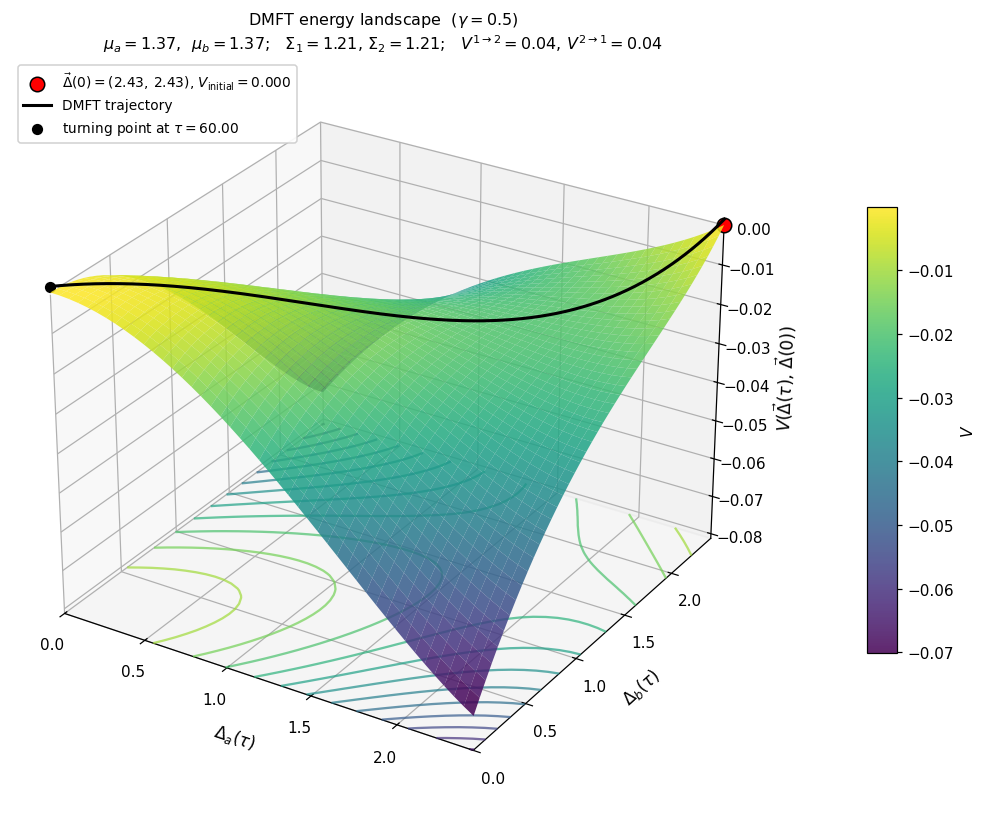

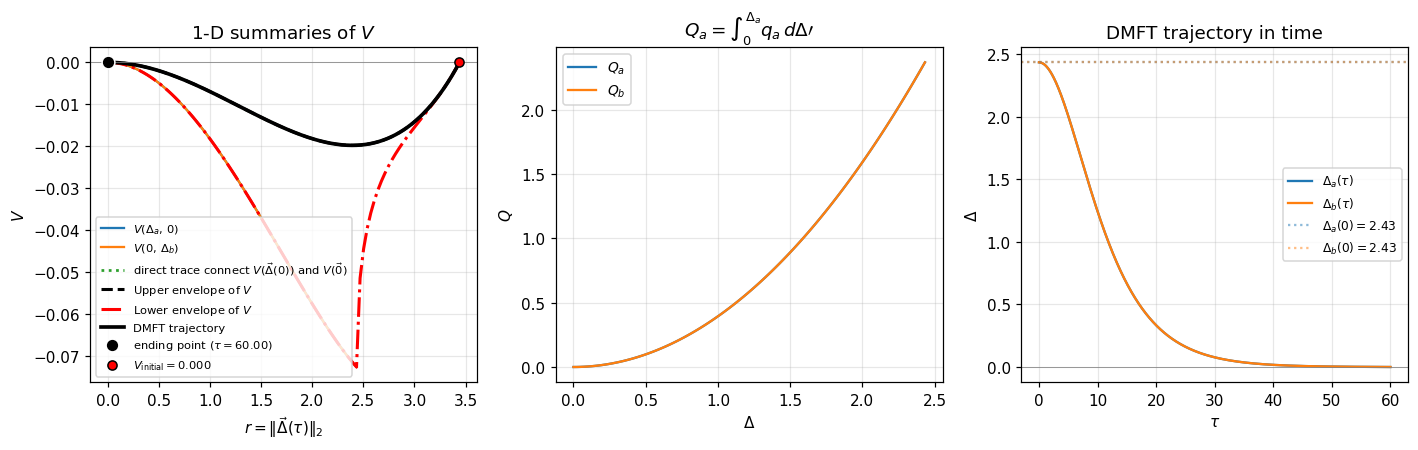

In [9]:
# Symmetric two-area network: both areas identical, equal cross-coupling.
p_sym = make_params(
    J_exc=0.05, J_cross=0.03, s_cross=0.05,
    g_inh=4.5, f_exc=0.8, N=1000, s=0.1,
    I_ext=0.0, gamma=GAMMA_DEFAULT, phi_max=np.inf,
)

sol_sym, traj_sym = landscape_from_micro(
    p_sym, label="symmetric", tau_max=60.0, max_step=0.01,
    save_prefix="energy_landscape_positive_symmetric",
)

## 9. Asymmetric example

Unequal cross-coupling $J_{\rm cross}^{0\to1}=0.03 \neq J_{\rm cross}^{1\to0}=0.02$. Both
directions are present, so $M_{\rm random}$ is asymmetric and the symmetriser
$D=\mathrm{diag}\!\big(\sqrt{V^{1\to2}/V^{2\to1}},\,\sqrt{V^{2\to1}/V^{1\to2}}\big)\neq I$
weights the two areas by their relative cross-variance (the area-importance reading of the
document, with $D_{11}D_{22}=1$). The self-consistent solution gives unequal
$(\mu_a,\mu_b)$ and $(\Delta_a^0,\Delta_b^0)$.

[asymmetric]  rho_rand=1.237  lam_struct=0.480  chaotic=True  diverged=False
   self-consistent  mu=(0.42695702, 0.59277359)  Delta_0=(0.58309055, 0.78396730)  rate=[phi]=(0.968588, 1.139064)
   M_random =
[[1.2125 0.016 ]
 [0.036  1.2125]]
   trajectory: fired='Db_low'  tau_end=12.11  V_initial=-0.0003
   energy conservation: abs_drift=5.18e-12  (rel_to_scale=1.46e-09;  |E0|=3.30e-04 ~ 0 here)


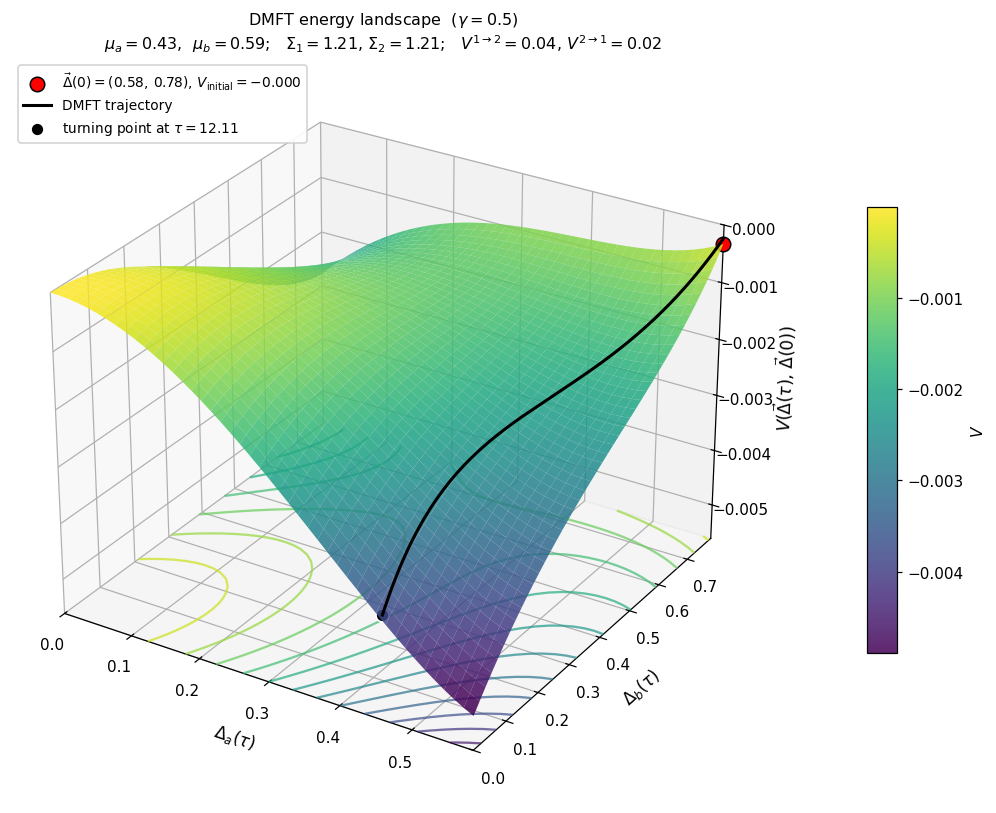

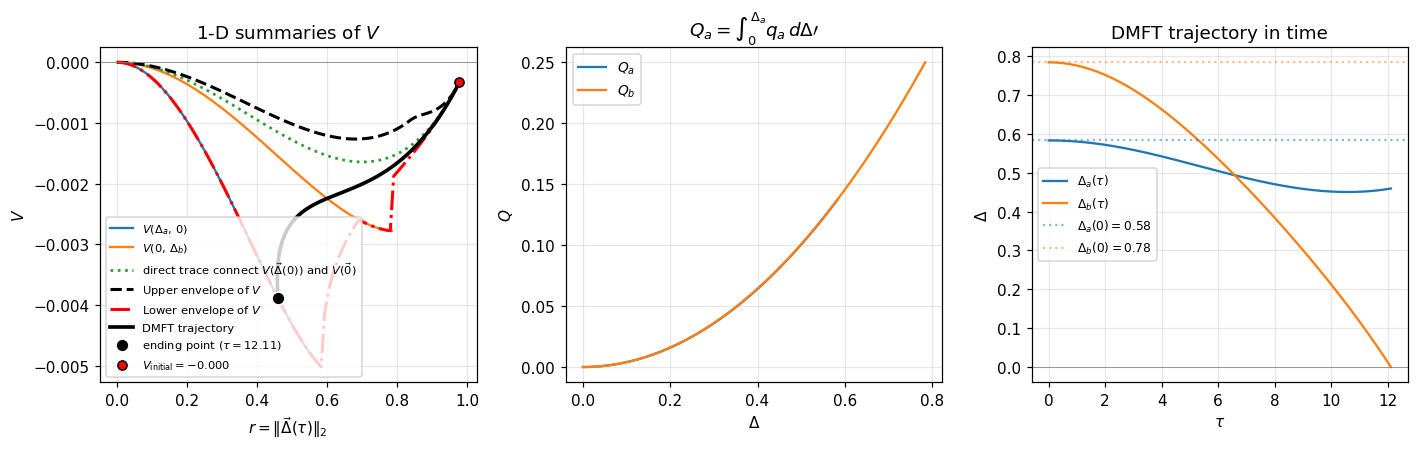

In [10]:
# Asymmetric two-area network: unequal cross-coupling, both directions present (D != I).
area0 = AreaParams(N=1000, s=0.1, f_exc=0.8, J_exc=0.05, g_inh=4.5)
area1 = AreaParams(N=1000, s=0.1, f_exc=0.8, J_exc=0.05, g_inh=4.5)
s_cross = np.zeros((2, 2)); s_cross[0, 1] = 0.05; s_cross[1, 0] = 0.05   # s_cross[src, tgt]
J_cross = np.zeros((2, 2)); J_cross[0, 1] = 0.03; J_cross[1, 0] = 0.02   # J_cross[src, tgt]
p_asy = MultiAreaParams(
    areas=(area0, area1), s_cross=s_cross, J_cross=J_cross,
    I_ext=np.zeros(2), gamma=GAMMA_DEFAULT, phi_max=np.inf,
)

sol_asy, traj_asy = landscape_from_micro(
    p_asy, label="asymmetric", tau_max=60.0, max_step=0.01,
    save_prefix="energy_landscape_positive_asymmetric",
)

## 10. Full-plane extension ($\Delta<0$): anti-correlation and the asymmetric caveat

The positive-plane sections above restrict $\Delta_a(\tau)\in[0,\Delta_a^0]$. Physically the
autocorrelation lives on the full Cauchy–Schwarz interval $\Delta_a(\tau)\in[-\Delta_a^0,\Delta_a^0]$:
$\Delta<0$ is **anti-correlation** ($\rho=\Delta/\Delta_0<0$). Here we build the landscape and
trajectory on the full box $[-\Delta_a^0,\Delta_a^0]\times[-\Delta_b^0,\Delta_b^0]$.

For $\Delta<0$ the Gaussian decomposition carries a sign flip on the common mode (eq. of
`C_a_fp`): $X(t)=\mu+az+by_1$, $X(t{+}\tau)=\mu-az+by_2$ with $a=\sqrt{|\Delta|}$,
$b=\sqrt{\Delta_0-|\Delta|}$, giving $\mathrm{cov}=-a^2=\Delta<0$. The inner $y$-integral is the
exact closed-form `mean_phi`; the outer $z$-integral is adaptive (accurate at the activation function kink),
and the positive endpoint is anchored to the closed-form `Q_diag` (so $V(\vec\Delta_0)=0$ holds for
symmetric/decaying chaos, as in §3).

**Trajectory rule (this section):** integrate to $\tau=60$ **or** the first physical box exit
$|\Delta_a|=\Delta_a^0$ / $|\Delta_b|=\Delta_b^0$ — the turning-point criterion is dropped.

**Asymmetric caveat (important).** The per-area $\Delta_0^a=\sqrt{2\sum_b M_{ab}Q_b}$ is exact only
when $\Delta_a(\tau)=\Delta_b(\tau)$ (symmetric). For unequal areas the energy-balance cross-term
$\int\dot\Delta_a q_b\,d\tau\neq Q_b$, so $V(\vec\Delta_0)\neq0$ and the trajectory cannot decay to
the origin (it exits the box / dips into anti-correlation). The exact asymmetric solution is a
**saddle-connection** (the origin is a clean saddle — see the diagnostic — with a 2-D stable
manifold the orbit must land on exactly); computing it robustly needs dedicated continuation
software and is left as future work. Below, the symmetric example is exact; the asymmetric example
uses the per-area solver and is flagged where $V_{\rm initial}\neq0$.

In [11]:
# ---- Full-plane accurate per-area machinery (Delta in [-Delta0, Delta0]) ----

def C_a_fp(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
           epsabs=1e-11, epsrel=1e-11, limit=200):
    """Full-plane C_a(Delta, Delta0) = E[phi(X(t)) phi(X(t+tau))] for the bivariate
    Gaussian with correlation rho = Delta/Delta0 in [-1, 1]. For Delta < 0 the common
    mode z carries a sign flip (anti-correlation). The inner y-integral is the exact
    closed-form `mean_phi`; the outer z-integral is adaptive (accurate at the kink)."""
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, -Delta0, Delta0))
    a = math.sqrt(abs(Delta))
    rem = max(Delta0 - abs(Delta), 0.0)          # = b^2 (variance of the private mode)
    if a == 0.0:                                  # independent -> <phi>^2
        return mean_phi(mu, Delta0, gamma, phi_max) ** 2
    s = 1.0 if Delta >= 0.0 else -1.0

    def integrand(z):
        i1 = mean_phi(mu + a * z, rem, gamma, phi_max)
        i2 = i1 if s > 0 else mean_phi(mu - a * z, rem, gamma, phi_max)
        return GAUSS_NORM * math.exp(-0.5 * z * z) * i1 * i2

    val, _ = quad(integrand, -np.inf, np.inf, epsabs=epsabs, epsrel=epsrel, limit=limit)
    return float(val)


def q_a_fp(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT, phim=None):
    """q_a = C_a_fp - <phi>^2, valid for Delta in [-Delta0, Delta0]."""
    if phim is None:
        phim = mean_phi(mu, Delta0, gamma, phi_max)
    return C_a_fp(Delta, Delta0, mu, gamma, phi_max) - phim ** 2


def Q_a_grid_fp(Delta_grid, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                n_quad=None, anchor=True):
    """Q_a on a signed grid spanning [-Delta0, Delta0]: Q_a(Delta) = int_0^Delta q_a dDelta'.
    Anchored so Q_a(0)=0. With anchor=True the POSITIVE side is rescaled so Q_a(+Delta0)
    equals the exact closed-form Q_diag (kills the large-Delta0 near-cancellation; q is
    rescaled by the same factor so Q stays the integral of q). The negative side relies on
    the adaptive accuracy (no closed-form endpoint there). `n_quad` is accepted and ignored
    (kept for call-compatibility with the positive-plane signature)."""
    phim = mean_phi(mu, Delta0, gamma, phi_max)
    q_vals = np.array([q_a_fp(d, Delta0, mu, gamma, phi_max, phim) for d in Delta_grid])
    Q = cumulative_trapezoid(q_vals, Delta_grid, initial=0.0)
    Q = Q - float(np.interp(0.0, Delta_grid, Q))          # anchor Q(0)=0
    if anchor:
        pos = Delta_grid > 1e-12
        if pos.any() and abs(float(Delta_grid[-1]) - Delta0) < 1e-9 and Q[-1] > 1e-14:
            s_pos = Q_diag(mu, Delta0, gamma, phi_max) / Q[-1]
            Q = Q.copy(); q_vals = q_vals.copy()
            Q[pos] *= s_pos
            q_vals[pos] *= s_pos
    return Q, q_vals


def compute_V_surface_fp(Delta_a_grid, Delta_b_grid, Delta_a_0, Delta_b_0,
                         mu_a, mu_b, M_random,
                         gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT, n_quad=None):
    """Full-plane V(Delta_a, Delta_b) = -1/2 Delta^T G Delta + sum_a D_aa Q_a, on the
    signed meshgrid (indexing='ij'). Same convention as the positive-plane compute_V_surface."""
    D, G = compute_D_G(M_random)
    Qa, _ = Q_a_grid_fp(Delta_a_grid, Delta_a_0, mu_a, gamma, phi_max)
    Qb, _ = Q_a_grid_fp(Delta_b_grid, Delta_b_0, mu_b, gamma, phi_max)
    Da, Db = np.meshgrid(Delta_a_grid, Delta_b_grid, indexing='ij')
    quad = -0.5 * (G[0, 0] * Da ** 2 + 2.0 * G[0, 1] * Da * Db + G[1, 1] * Db ** 2)
    V = quad + D[0, 0] * Qa[:, None] + D[1, 1] * Qb[None, :]
    return V, Da, Db, D, G, Qa, Qb

In [12]:
def plot_V_landscape_fp(mu_a, mu_b, M_random, Delta_a_0, Delta_b_0,
                     gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                     n_quad=41, n_grid=40,
                     show_initial=True, show_contour=True,
                     figsize=(10.5, 7.5), elev=28, azim=-58,
                     cmap='viridis', return_data=False, ax=None,
                     traj=None):
    """Render the 3-D DMFT energy landscape on the full Cauchy-Schwarz box.

    V is built on [-Delta_a_0, +Delta_a_0] x [-Delta_b_0, +Delta_b_0] so the
    trajectory's anti-correlation excursions (Delta < 0) are visible. The IC
    is at (+Delta_a_0, +Delta_b_0), kept marked in red.
    """
    Da_grid = np.linspace(-Delta_a_0, Delta_a_0, n_grid)
    Db_grid = np.linspace(-Delta_b_0, Delta_b_0, n_grid)

    V, Da, Db, D, G, Qa, Qb = compute_V_surface_fp(
        Da_grid, Db_grid, Delta_a_0, Delta_b_0,
        mu_a, mu_b, M_random, gamma=gamma, phi_max=phi_max, n_quad=n_quad,
    )

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = ax.figure

    surf = ax.plot_surface(
        Da, Db, V, cmap=cmap, alpha=0.85, linewidth=0,
        antialiased=True, rstride=1, cstride=1,
    )

    if show_contour:
        offset = V.min() - 0.12 * (V.max() - V.min() + 1e-12)
        ax.contour(Da, Db, V, levels=12, cmap=cmap, offset=offset, alpha=0.7)
        # Thin reference lines on the floor at Delta_a=0 and Delta_b=0
        ax.plot([0, 0], [-Delta_b_0, Delta_b_0], [offset, offset],
                color='gray', lw=0.6, alpha=0.7)
        ax.plot([-Delta_a_0, Delta_a_0], [0, 0], [offset, offset],
                color='gray', lw=0.6, alpha=0.7)
        ax.set_zlim(offset, max(V.max() * 1.05, 1e-6))

    if show_initial:
        V_init = V[-1, -1]  # corner: (Delta_a_0, Delta_b_0)
        ax.scatter([Delta_a_0], [Delta_b_0], [V_init],
                   color='red', s=90, edgecolor='k', depthshade=False,
                   label=fr'$\vec\Delta(0)=({Delta_a_0:.2f},\,{Delta_b_0:.2f})$, '
                         fr'$V_{{\mathrm{{initial}}}}={V_init:.3f}$')

    if traj is not None:
        z_pad = 0.02 * (V.max() - V.min() + 1e-12)
        ax.plot(traj['Delta_a'], traj['Delta_b'], traj['V'] + z_pad,
                color='black', lw=2.0, zorder=6,
                label='DMFT trajectory')
        ax.scatter([traj['Delta_a'][-1]], [traj['Delta_b'][-1]],
                   [traj['V'][-1] + z_pad],
                   color='black', s=70, edgecolor='white', depthshade=False,
                   label=fr'turning(ending) point at $\tau={traj["tau"][-1]:.2f}$')

    if show_initial or (traj is not None):
        ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

    ax.set_xlim(-Delta_a_0, Delta_a_0)
    ax.set_ylim(-Delta_b_0, Delta_b_0)
    ax.set_xmargin(0)
    ax.set_ymargin(0)

    ax.set_xlabel(r'$\Delta_a(\tau)$', fontsize=11, labelpad=6)
    ax.set_ylabel(r'$\Delta_b(\tau)$', fontsize=11, labelpad=6)
    ax.set_zlabel(r'$V(\vec\Delta(\tau),\,\vec\Delta(0))$', fontsize=11, labelpad=6)
    ax.view_init(elev=elev, azim=azim)

    title = (
        fr'DMFT energy landscape  ($\gamma={gamma}$)' + '\n'
        fr'$\mu_a={mu_a:.2f}$,  $\mu_b={mu_b:.2f}$;   '
        fr'$\Sigma_1={M_random[0,0]:.2f}$, $\Sigma_2={M_random[1,1]:.2f}$;   '
        fr'$V^{{1\to 2}}={M_random[1,0]:.2f}$, $V^{{2\to 1}}={M_random[0,1]:.2f}$'
    )
    ax.set_title(title, fontsize=10.5)
    fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.10, label=r'$V$')
    plt.tight_layout()

    if return_data:
        return fig, ax, dict(V=V, Da=Da, Db=Db, D=D, G=G, Qa=Qa, Qb=Qb)
    return fig, ax

In [13]:
def radial_envelopes_from_surface_fp(Da_grid, Db_grid, V,
                                  Delta_a_0, Delta_b_0,
                                  n_r=None, n_theta=721):
    """
    Geometric radial envelopes of V over the full Cauchy-Schwarz box
    [-Delta_a_0, +Delta_a_0] x [-Delta_b_0, +Delta_b_0].

    For each radius r in [0, sqrt(Delta_a_0^2 + Delta_b_0^2)], sweep
    theta in [0, 2 pi). Only keep sample points that fall inside the box.
    Returns:
      V_upper(r) = max_theta V(r cos theta, r sin theta),
      V_lower(r) = min_theta V(r cos theta, r sin theta),
    and the (Delta_a, Delta_b) points that achieve them.

    Used by the 2-D color plot (cell 28) for tracing the max/min loci.
    """
    from scipy.interpolate import RegularGridInterpolator

    if n_r is None:
        n_r = max(len(Da_grid), len(Db_grid))

    interp_V = RegularGridInterpolator(
        (Da_grid, Db_grid), V, bounds_error=False, fill_value=np.nan,
    )

    r_max = float(np.hypot(Delta_a_0, Delta_b_0))
    r_vals = np.linspace(0.0, r_max, n_r)

    V_upper = np.full_like(r_vals, np.nan, dtype=float)
    V_lower = np.full_like(r_vals, np.nan, dtype=float)
    upper_points = np.full((len(r_vals), 2), np.nan, dtype=float)
    lower_points = np.full((len(r_vals), 2), np.nan, dtype=float)

    theta_full = np.linspace(0.0, 2.0 * np.pi, n_theta, endpoint=False)

    for i, r in enumerate(r_vals):
        if r <= 1e-15:
            pts = np.array([[0.0, 0.0]])
        else:
            pts = np.column_stack([r * np.cos(theta_full),
                                   r * np.sin(theta_full)])
            inside = ((np.abs(pts[:, 0]) <= Delta_a_0 + 1e-12) &
                      (np.abs(pts[:, 1]) <= Delta_b_0 + 1e-12))
            pts = pts[inside]
            if len(pts) == 0:
                continue

        vals = interp_V(pts)
        if np.all(np.isnan(vals)):
            continue

        j_max = int(np.nanargmax(vals))
        j_min = int(np.nanargmin(vals))

        V_upper[i] = vals[j_max]
        V_lower[i] = vals[j_min]
        upper_points[i] = pts[j_max]
        lower_points[i] = pts[j_min]

    return r_vals, V_upper, V_lower, upper_points, lower_points


def radial_envelopes_signed_fp(Da_grid, Db_grid, V,
                            Delta_a_0, Delta_b_0,
                            n_r=None, n_theta=721):
    """Radial envelopes parameterised by signed radius
        s = sign(Delta . Delta_0) * ||Delta||_2 ,
    so that s in [-r_max, +r_max].

    The +s envelope sweeps the half-plane Δ·Δ_0 > 0 (aligned with the IC
    direction Δ_0 = (Delta_a_0, Delta_b_0)); the -s envelope sweeps the
    opposite half-plane. Both halves are intersected with the
    Cauchy-Schwarz box [-Delta_a_0, +Delta_a_0] x [-Delta_b_0, +Delta_b_0].

    Note: the off-diagonal halves of Q2/Q4 are included — that is where
    the lower-envelope optima typically lie.

    Returns (s_grid, V_upper, V_lower, upper_pts, lower_pts) with
    s_grid of length 2*n_r - 1, monotonically increasing from -r_max
    through 0 to +r_max.
    """
    from scipy.interpolate import RegularGridInterpolator

    if n_r is None:
        n_r = max(len(Da_grid), len(Db_grid))

    interp_V = RegularGridInterpolator(
        (Da_grid, Db_grid), V, bounds_error=False, fill_value=np.nan,
    )

    r_max = float(np.hypot(Delta_a_0, Delta_b_0))
    r_abs = np.linspace(0.0, r_max, n_r)
    s_grid = np.concatenate([-r_abs[:0:-1], r_abs])  # drop duplicate 0
    N = len(s_grid)
    V_upper = np.full(N, np.nan)
    V_lower = np.full(N, np.nan)
    upper_pts = np.full((N, 2), np.nan)
    lower_pts = np.full((N, 2), np.nan)

    theta_full = np.linspace(0.0, 2.0 * np.pi, n_theta, endpoint=False)
    i_zero = n_r - 1  # index of s = 0 in s_grid

    for i, r in enumerate(r_abs):
        if r <= 1e-15:
            v0 = float(interp_V([[0.0, 0.0]])[0])
            V_upper[i_zero] = v0
            V_lower[i_zero] = v0
            upper_pts[i_zero] = [0.0, 0.0]
            lower_pts[i_zero] = [0.0, 0.0]
            continue

        pts = np.column_stack([r * np.cos(theta_full),
                               r * np.sin(theta_full)])
        inside = ((np.abs(pts[:, 0]) <= Delta_a_0 + 1e-12) &
                  (np.abs(pts[:, 1]) <= Delta_b_0 + 1e-12))
        pts = pts[inside]
        if len(pts) == 0:
            continue

        # Half-plane filter (aligned vs anti-aligned with the IC direction):
        #   +s envelope sweeps Δ·Δ_0 > 0  (Q1 + half of Q2 + half of Q4)
        #   -s envelope sweeps Δ·Δ_0 < 0  (Q3 + the other halves of Q2/Q4)
        # The off-diagonal halves of Q2/Q4 typically hold the lower-envelope optima.
        dots = pts[:, 0] * Delta_a_0 + pts[:, 1] * Delta_b_0
        pos = dots > 0
        neg = dots < 0
        vals = interp_V(pts)

        # Positive half: s = +r
        if np.any(pos):
            v_pos = vals[pos]; p_pos = pts[pos]
            if not np.all(np.isnan(v_pos)):
                j_max = int(np.nanargmax(v_pos))
                j_min = int(np.nanargmin(v_pos))
                k = i_zero + i
                V_upper[k] = v_pos[j_max]; upper_pts[k] = p_pos[j_max]
                V_lower[k] = v_pos[j_min]; lower_pts[k] = p_pos[j_min]

        # Negative half: s = -r
        if np.any(neg):
            v_neg = vals[neg]; p_neg = pts[neg]
            if not np.all(np.isnan(v_neg)):
                j_max = int(np.nanargmax(v_neg))
                j_min = int(np.nanargmin(v_neg))
                k = i_zero - i
                V_upper[k] = v_neg[j_max]; upper_pts[k] = p_neg[j_max]
                V_lower[k] = v_neg[j_min]; lower_pts[k] = p_neg[j_min]

    return s_grid, V_upper, V_lower, upper_pts, lower_pts


def plot_V_diagnostics_fp(mu_a, mu_b, M_random, Delta_a_0, Delta_b_0,
                       gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                       n_quad=41, n_grid=100, n_theta=721,
                       figsize=(13, 4.2), traj=None):
    """1-D diagnostics of V over the full Cauchy-Schwarz box.

    Panels:
      1. V vs signed radius  s = sign(Delta . Delta_0) * ||Delta||_2.
         All curves share this single x-axis: axis slices V(Delta_a, 0)
         and V(0, Delta_b) (where s reduces to the signed coordinate),
         the origin -> IC ray, the radial upper/lower envelopes (signed
         version), the DMFT trajectory, and the V_initial marker.
      2. Per-area centred autocorrelation q_a(Delta, Delta_0) on the
         signed grid.
      3. Q_a(Delta, Delta_0) on the signed grid.
      4. (When `traj` is provided) Delta_a(tau), Delta_b(tau) vs tau.
    """
    from scipy.interpolate import RegularGridInterpolator

    Da_grid = np.linspace(-Delta_a_0, Delta_a_0, n_grid)
    Db_grid = np.linspace(-Delta_b_0, Delta_b_0, n_grid)

    V, _, _, D, G, Qa, Qb = compute_V_surface_fp(
        Da_grid, Db_grid, Delta_a_0, Delta_b_0,
        mu_a, mu_b, M_random, gamma=gamma, phi_max=phi_max, n_quad=n_quad,
    )

    interp_V = RegularGridInterpolator(
        (Da_grid, Db_grid), V, bounds_error=False, fill_value=np.nan,
    )

    # Helper: signed radius along the IC direction
    def signed_r(Delta_a, Delta_b):
        return np.sign(Delta_a * Delta_a_0 + Delta_b * Delta_b_0) * \
               np.hypot(Delta_a, Delta_b)

    # Anti-correlated boundary slices replacing V(Δ_a, 0) and V(0, Δ_b):
    #   bottom edge:  V(Δ_a, -Δ_b^0)   for Δ_a ∈ [-Δ_a^0, +Δ_a^0]
    #   left edge:    V(-Δ_a^0, -Δ_b) for Δ_b ∈ [-Δ_b^0, +Δ_b^0]
    # (The second slice negates Δ_b in the y-coordinate per user notation.)
    edge_bot_pts = np.column_stack(
        [Da_grid, np.full_like(Da_grid, -Delta_b_0)]
    )
    edge_left_pts = np.column_stack(
        [np.full_like(Db_grid, -Delta_a_0), -Db_grid]
    )
    V_bot  = interp_V(edge_bot_pts)
    V_left = interp_V(edge_left_pts)

    # Origin -> IC ray (s in [0, +r_max])
    r0 = float(np.hypot(Delta_a_0, Delta_b_0))
    alpha = np.linspace(0.0, 1.0, n_grid)
    ray_points = np.column_stack([alpha * Delta_a_0, alpha * Delta_b_0])
    V_ray = interp_V(ray_points)
    s_ray = signed_r(ray_points[:, 0], ray_points[:, 1])
    V_initial = float(V_ray[-1])

    # Signed-radius envelopes over the full Cauchy-Schwarz box
    s_env, V_upper_s, V_lower_s, upper_pts_s, lower_pts_s = \
        radial_envelopes_signed_fp(
            Da_grid, Db_grid, V, Delta_a_0, Delta_b_0,
            n_r=n_grid, n_theta=n_theta,
        )

    _, q_a_vals = Q_a_grid_fp(Da_grid, Delta_a_0, mu_a, gamma, phi_max, n_quad)
    _, q_b_vals = Q_a_grid_fp(Db_grid, Delta_b_0, mu_b, gamma, phi_max, n_quad)

    n_panels = 3 if traj is not None else 3
    fig, axes = plt.subplots(
        1, n_panels, figsize=(figsize[0] * n_panels / 3, figsize[1])
    )

    # ----- Panel 1: 1-D summaries of V on a unified signed-radius axis -----
    ax = axes[0]
    # Axis slices: on the Delta_a-axis, signed_r = Delta_a (and same for b)
    # because Delta_a_0 > 0 and Delta_b_0 > 0.
    s_bot  = signed_r(edge_bot_pts[:, 0],  edge_bot_pts[:, 1])
    s_left = signed_r(edge_left_pts[:, 0], edge_left_pts[:, 1])
    # ax.plot(s_bot,  V_bot,  label=r'$V(\Delta_a,\,-\Delta_b(0))$')
    # ax.plot(s_left, V_left, label=r'$V(-\Delta_a(0),\,-\Delta_b)$')
    ax.plot(s_ray, V_ray, linestyle=':', lw=1.8,
            label=r'origin$\to\vec\Delta(0)$ ray')
    ax.plot(s_env, V_upper_s, linestyle='--', color='black', lw=2.0,
            label=r'Upper envelope of $V$')
    ax.plot(s_env, V_lower_s, linestyle='-.', color='red', lw=2.0,
            label=r'Lower envelope of $V$')
    if traj is not None:
        s_traj = signed_r(traj['Delta_a'], traj['Delta_b'])
        ax.plot(s_traj, traj['V'], color='black', lw=2.4,
                label='DMFT trajectory')
        ax.scatter([s_traj[-1]], [traj['V'][-1]], color='black',
                   edgecolor='white', s=70, zorder=6,
                   label=fr'ending point ($\tau={traj["tau"][-1]:.2f}$)')
    ax.scatter([r0], [V_initial], color='red', edgecolor='k', zorder=5,
               label=fr'$V_{{\rm initial}}={V_initial:.3f}$')
    ax.axhline(0.0, color='gray', lw=0.5)
    ax.axvline(0.0, color='gray', lw=0.5)
    ax.set_xlabel(r'signed radius  '
                  r'$s=\mathrm{sgn}(\vec\Delta\cdot\vec\Delta_0)\,\|\vec\Delta\|_2$')
    ax.set_ylabel(r'$V$')
    ax.set_title('1-D summaries of $V$')
    ax.legend(fontsize=7.5, loc='best')
    ax.grid(alpha=0.3)

    # ----- Panel 2: q_a and q_b -----
    # ax = axes[1]
    # ax.plot(Da_grid, q_a_vals, label=r'$q_a(\Delta_a,\Delta_a^0)$')
    # ax.plot(Db_grid, q_b_vals, label=r'$q_b(\Delta_b,\Delta_b^0)$')
    # ax.axhline(0.0, color='gray', lw=0.5)
    # ax.axvline(0.0, color='gray', lw=0.5)
    # ax.set_xlabel(r'$\Delta$'); ax.set_ylabel(r'$q$')
    # ax.set_title('Per-area centred autocorrelation')
    # ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ----- Panel 3: Q_a and Q_b -----
    ax = axes[1]
    ax.plot(Da_grid, Qa, label=r'$Q_a$')
    ax.plot(Db_grid, Qb, label=r'$Q_b$')
    ax.axhline(0.0, color='gray', lw=0.5)
    ax.axvline(0.0, color='gray', lw=0.5)
    ax.set_xlabel(r'$\Delta$'); ax.set_ylabel(r'$Q$')
    ax.set_title(r'$Q_a = \int_0^{\Delta_a} q_a\, d\Delta\prime$')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ----- Panel 4 (optional): Delta_a(tau), Delta_b(tau) -----
    if traj is not None:
        ax = axes[2]
        ax.plot(traj['tau'], traj['Delta_a'], label=r'$\Delta_a(\tau)$')
        ax.plot(traj['tau'], traj['Delta_b'], label=r'$\Delta_b(\tau)$')
        ax.axhline(Delta_a_0, color='C0', ls=':', alpha=0.5,
                   label=fr'$\Delta_a(0)={Delta_a_0:.2f}$')
        ax.axhline(Delta_b_0, color='C1', ls=':', alpha=0.5,
                   label=fr'$\Delta_b(0)={Delta_b_0:.2f}$')
        # ax.axhline(-Delta_a_0, color='C0', ls=':', alpha=0.5,
        #            label=fr'$-\Delta_a(0)={-Delta_a_0:.2f}$')
        # ax.axhline(-Delta_b_0, color='C1', ls=':', alpha=0.5,
        #            label=fr'$-\Delta_b(0)={-Delta_b_0:.2f}$')
        # ax.axhline(0.0, color='gray', lw=0.5)
        ax.set_xlabel(r'$\tau$'); ax.set_ylabel(r'$\Delta$')
        ax.set_title('DMFT trajectory in time')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()

    diagnostics = dict(
        D=D, G=G, V=V, Da_grid=Da_grid, Db_grid=Db_grid,
        s_env=s_env, V_upper_s=V_upper_s, V_lower_s=V_lower_s,
        upper_pts_s=upper_pts_s, lower_pts_s=lower_pts_s,
        s_ray=s_ray, V_ray=V_ray, V_initial=V_initial,
    )
    return fig, axes, diagnostics

In [14]:
# ---- Full-plane trajectory: integrate to tau=60 OR first physical box exit |Delta|=Delta0 ----

def dmft_origin_diagnostics(mu, Delta_0, M_random,
                            gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Linearisation of ddot{Delta}=Delta-M q at the origin: A = M diag(kappa) - I with
    kappa_a = q_a'(0) = <phi'>_a^2. Reports the J = [[0,I],[-A,0]] eigenvalues; the origin is
    a clean saddle (decaying chaos) when all four are real with 2 positive + 2 negative."""
    def _mphip(m, d0):
        sg = math.sqrt(max(d0, 1e-300))
        lo = 0.5 * (1.0 + math.erf((-gamma - m) / sg / SQRT2))
        hi = 1.0 if not np.isfinite(phi_max) else 0.5 * (1.0 + math.erf((phi_max - gamma - m) / sg / SQRT2))
        return hi - lo
    kap = np.array([_mphip(mu[a], Delta_0[a]) ** 2 for a in range(2)])
    A = M_random * kap[None, :] - np.eye(2)
    Jm = np.block([[np.zeros((2, 2)), np.eye(2)], [-A, np.zeros((2, 2))]])
    jev = np.linalg.eigvals(Jm)
    clean = bool(np.all(np.abs(jev.imag) < 1e-7)
                 and np.sum(jev.real > 1e-9) == 2 and np.sum(jev.real < -1e-9) == 2)
    return dict(kappa=kap, A_eig=np.linalg.eigvals(A), J_eig=jev, clean_saddle=clean)


def integrate_dmft_fp(mu_a, mu_b, M_random, Delta_a_0, Delta_b_0,
                      *, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                      tau_max=60.0, rtol=1e-9, atol=1e-12, max_step=0.02,
                      n_qgrid=1200, eps_rel=1e-6):
    """Integrate eq.(125) to tau_max OR the first box exit at |Delta_a|=Delta_a_0 /
    |Delta_b|=Delta_b_0 (Cauchy-Schwarz bound). NO turning-point criterion. Force and
    potential share one adaptive full-plane q-table (energy-consistent); V uses the exact
    integral of that table's interpolant (see _Q_from_qtable)."""
    D, G = compute_D_G(M_random)
    ga = np.linspace(-Delta_a_0, Delta_a_0, n_qgrid)
    gb = np.linspace(-Delta_b_0, Delta_b_0, n_qgrid)
    Qa_tab, qa_tab = Q_a_grid_fp(ga, Delta_a_0, mu_a, gamma, phi_max, anchor=True)
    Qb_tab, qb_tab = Q_a_grid_fp(gb, Delta_b_0, mu_b, gamma, phi_max, anchor=True)
    eps_a = eps_rel * Delta_a_0
    eps_b = eps_rel * Delta_b_0

    def rhs(tau, y):
        Da, Db, va, vb = y
        qa = np.interp(min(max(Da, -Delta_a_0), Delta_a_0), ga, qa_tab)
        qb = np.interp(min(max(Db, -Delta_b_0), Delta_b_0), gb, qb_tab)
        return [va, vb, Da - (M_random[0, 0] * qa + M_random[0, 1] * qb),
                Db - (M_random[1, 0] * qa + M_random[1, 1] * qb)]

    def ev_Da_high(tau, y): return (Delta_a_0 + eps_a) - y[0]
    def ev_Da_low(tau, y):  return y[0] - (-Delta_a_0 - eps_a)
    def ev_Db_high(tau, y): return (Delta_b_0 + eps_b) - y[1]
    def ev_Db_low(tau, y):  return y[1] - (-Delta_b_0 - eps_b)
    evs = [ev_Da_high, ev_Da_low, ev_Db_high, ev_Db_low]
    for ev in evs:
        ev.direction = -1.0; ev.terminal = True

    sol = solve_ivp(rhs, [0.0, tau_max], [Delta_a_0, Delta_b_0, 0.0, 0.0],
                    method='RK45', dense_output=True, events=evs,
                    rtol=rtol, atol=atol, max_step=max_step)
    names = ['Da_high', 'Da_low', 'Db_high', 'Db_low']
    fired = next((n for n, t in zip(names, sol.t_events) if len(t) > 0), 'none (reached tau_max)')

    tau = sol.t
    Da, Db, va, vb = sol.y
    T_vals = kinetic_energy(va, vb, G)
    Qa_t = _Q_from_qtable(np.clip(Da, -Delta_a_0, Delta_a_0), ga, qa_tab, Qa_tab)
    Qb_t = _Q_from_qtable(np.clip(Db, -Delta_b_0, Delta_b_0), gb, qb_tab, Qb_tab)
    quad = -0.5 * (G[0, 0] * Da ** 2 + 2.0 * G[0, 1] * Da * Db + G[1, 1] * Db ** 2)
    V_vals = quad + D[0, 0] * Qa_t + D[1, 1] * Qb_t
    return dict(tau=tau, Delta_a=Da, Delta_b=Db, Delta_a_dot=va, Delta_b_dot=vb,
                T=T_vals, V=V_vals, E=T_vals + V_vals, V_initial=float(V_vals[0]),
                G=G, D=D, status=sol.status, message=sol.message, fired_event=fired)

In [15]:
def fullplane_from_micro(p, *, tau_max=60.0, max_step=0.02, n_grid=50,
                         chaos_tol=1e-4, label="", save_prefix=None):
    """Micro-parameters -> self-consistent (mu, Delta_0, M_random) -> FULL-PLANE landscape +
    1-D statistics + 60s/box trajectory. Prints V_initial, the origin saddle diagnostic, and a
    caveat where V_initial != 0 (per-area Delta_0 approximate for unequal areas)."""
    rho_r, lam_s, mu_star, gain = linear_onsets(p)
    if (not np.isfinite(p.phi_max)) and lam_s >= 1.0:
        print(f"[{label}] structural mean runaway (lam_struct={lam_s:.3f}); no finite landscape.")
        return None, None
    sol = solve_selfconsistent(p, mu0=np.array(mu_star, float), D0_0=np.array([1.0, 1.0]))
    if sol['diverged'] or np.max(sol['Delta0']) < chaos_tol:
        print(f"[{label}] no fluctuating landscape (diverged or Delta_0~0).")
        return sol, None
    mu_a, mu_b = sol['mu']; Da0, Db0 = sol['Delta0']; M = sol['M_random']
    g_, pm = p.gamma, p.phi_max
    diag = dmft_origin_diagnostics(sol['mu'], sol['Delta0'], M, g_, pm)
    traj = integrate_dmft_fp(mu_a, mu_b, M, Da0, Db0, gamma=g_, phi_max=pm,
                             tau_max=tau_max, max_step=max_step)
    anti = bool(traj['Delta_a'].min() < -1e-3 * Da0 or traj['Delta_b'].min() < -1e-3 * Db0)
    print(f"[{label}]  mu=({mu_a:.4f}, {mu_b:.4f})  Delta_0=({Da0:.4f}, {Db0:.4f})")
    print(f"   V_initial = {traj['V_initial']:+.4e}   (= 0 expected for symmetric / decaying chaos)")
    print(f"   origin: clean_saddle={diag['clean_saddle']}  J_eigenvalues={np.round(diag['J_eig'].real, 4)}")
    print(f"   trajectory: fired={traj['fired_event']!r}  tau_end={traj['tau'][-1]:.2f}  "
          f"Delta_a in [{traj['Delta_a'].min():+.3f}, {traj['Delta_a'].max():+.3f}]  anti_correlation={anti}")
    if abs(traj['V_initial']) > 1e-4:        # V_init should be ~0; flag real (non-numerical) deviation
        print(f"   NOTE: V_initial != 0  ->  the per-area Delta_0 is only approximate here (areas "
              f"differ). The exact asymmetric solution is a saddle-connection BVP (see the note cell).")

    fig, ax = plot_V_landscape_fp(mu_a, mu_b, M, Da0, Db0, gamma=g_, phi_max=pm,
                                  n_grid=n_grid, traj=traj)
    if save_prefix:
        plt.savefig(f"{save_prefix}_landscape.png", dpi=300, bbox_inches="tight")
    plt.show()
    fig, axes, d = plot_V_diagnostics_fp(mu_a, mu_b, M, Da0, Db0, gamma=g_, phi_max=pm, traj=traj)
    if save_prefix:
        plt.savefig(f"{save_prefix}_1D.png", dpi=300, bbox_inches="tight")
    plt.show()
    return sol, traj

### 10.1 Symmetric example (full plane) — clean decay to the origin

Two identical areas (V_initial = 0). The trajectory rides down the symmetric landscape and
asymptotes to the origin, staying in the positive quadrant — no anti-correlation needed.

[symmetric (full plane)]  mu=(1.7626, 1.7626)  Delta_0=(15.1121, 15.1121)
   V_initial = +1.6835e-07   (= 0 expected for symmetric / decaying chaos)
   origin: clean_saddle=True  J_eigenvalues=[-0.3379 -0.2773  0.3379  0.2773]
   trajectory: fired='Da_low'  tau_end=50.34  Delta_a in [-15.112, +15.112]  anti_correlation=True


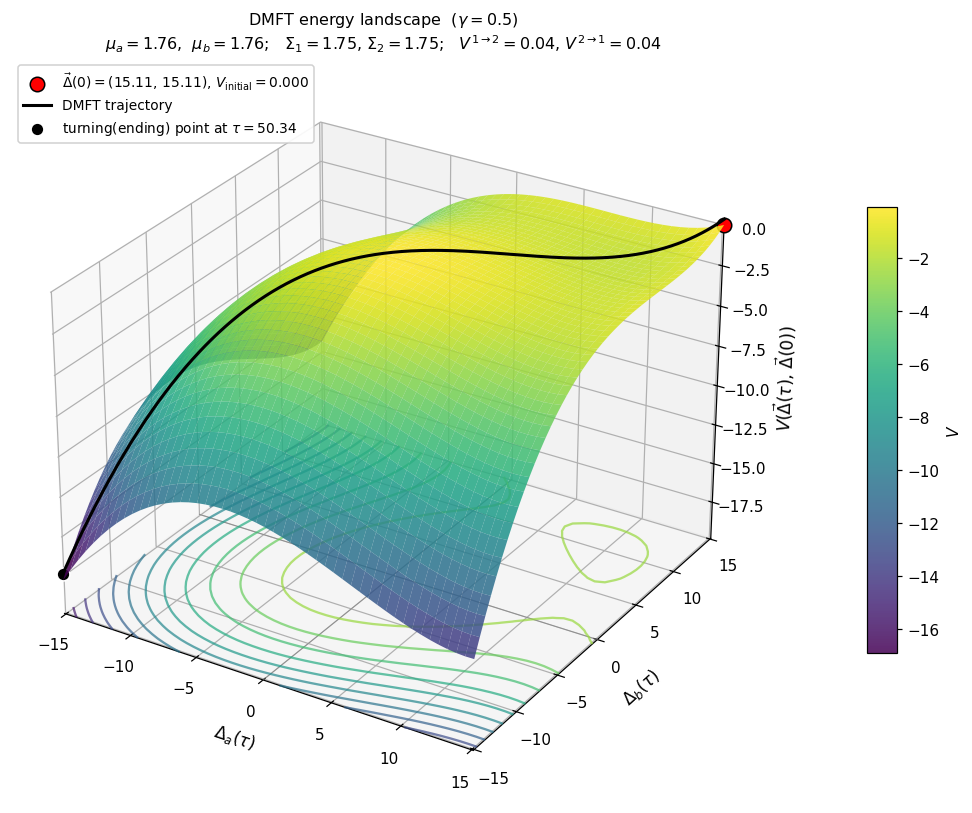

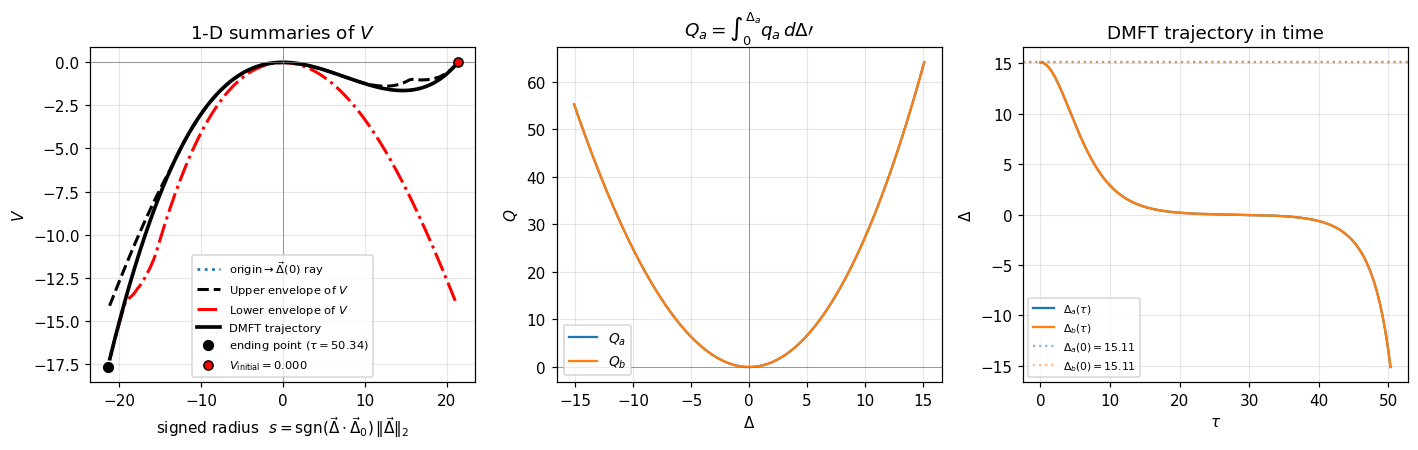

In [18]:
# Symmetric full-plane example.
p_sym_fp = make_params(
    J_exc=0.06, J_cross=0.03, s_cross=0.05,
    g_inh=4.5, f_exc=0.8, N=1000, s=0.1,
    I_ext=0.0, gamma=GAMMA_DEFAULT, phi_max=np.inf,
)
sol_sym_fp, traj_sym_fp = fullplane_from_micro(
    p_sym_fp, label="symmetric (full plane)", tau_max=60.0, max_step=0.02,
    save_prefix="fullplane_symmetric",
)

### 10.2 Asymmetric example (full plane) — per-area solver + saddle-connection caveat

Unequal cross-coupling. Here the per-area $\Delta_0$ gives $V_{\rm initial}\neq0$, so the
trajectory does **not** decay to the origin — it rolls to the box edge and into anti-correlation
($\Delta<0$). This is the visualization of the solver caveat; the exact decaying solution is the
saddle-connection discussed in the note cell.

[asymmetric (full plane)]  mu=(2.6433, 2.4189)  Delta_0=(6.9194, 6.1305)
   V_initial = -8.9011e-03   (= 0 expected for symmetric / decaying chaos)
   origin: clean_saddle=True  J_eigenvalues=[-0.2981 -0.152   0.2981  0.152 ]
   trajectory: fired='Db_high'  tau_end=14.90  Delta_a in [-4.185, +6.919]  anti_correlation=True
   NOTE: V_initial != 0  ->  the per-area Delta_0 is only approximate here (areas differ). The exact asymmetric solution is a saddle-connection BVP (see the note cell).


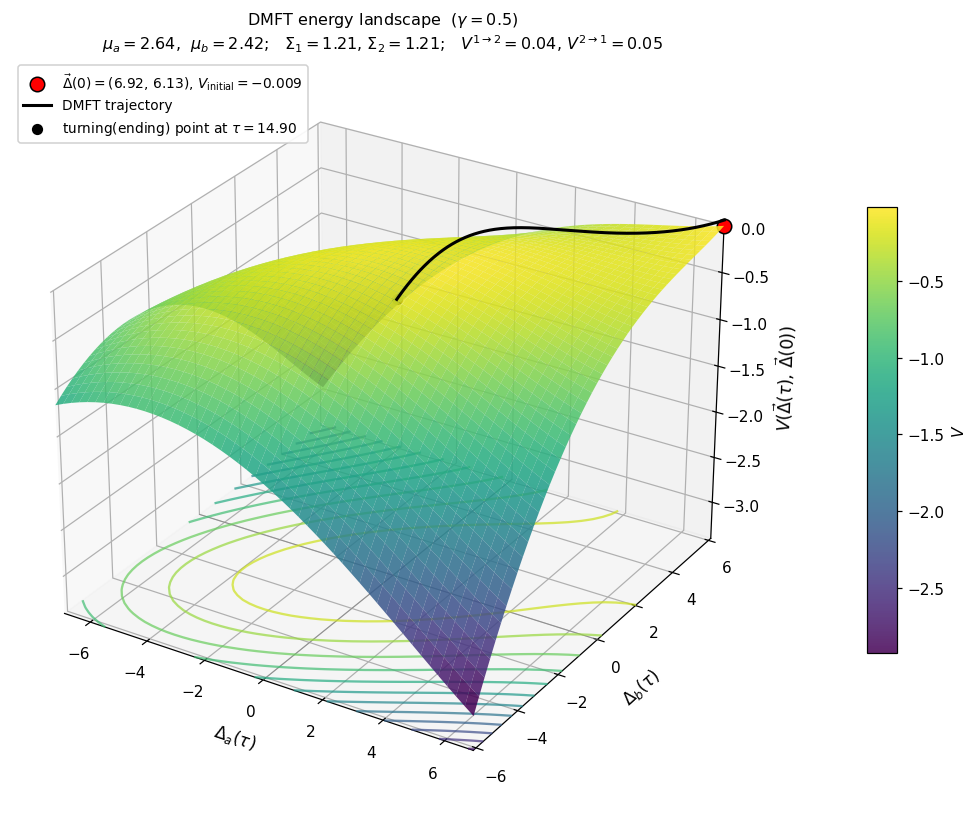

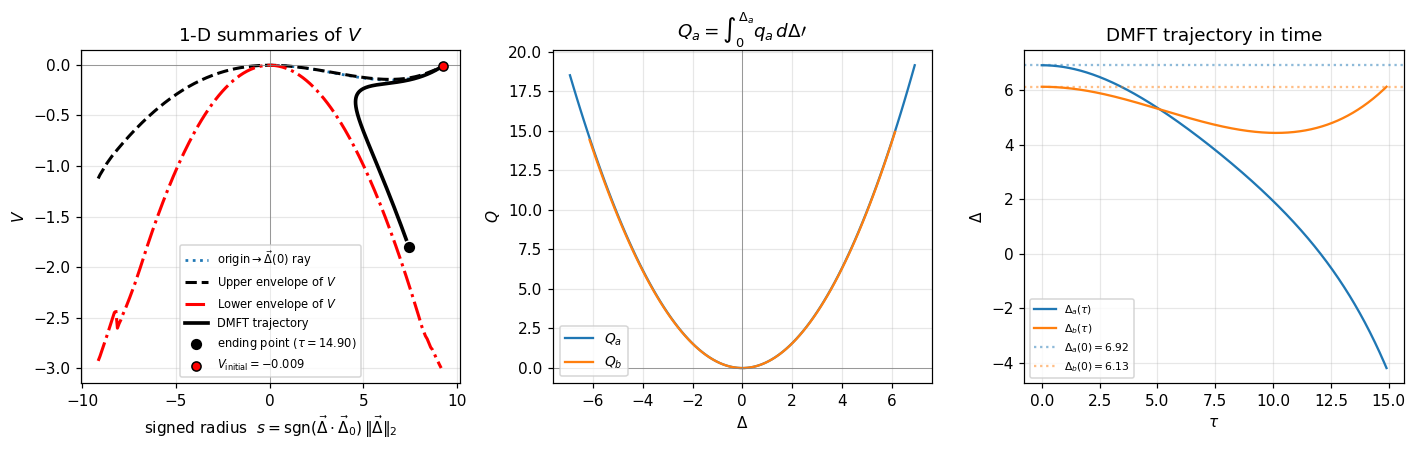

In [17]:
# Asymmetric full-plane example (per-area solver; V_initial != 0 expected).
area0_fp = AreaParams(N=1000, s=0.1, f_exc=0.8, J_exc=0.05, g_inh=4.5)
area1_fp = AreaParams(N=1000, s=0.1, f_exc=0.8, J_exc=0.05, g_inh=4.5)
s_cross_fp = np.zeros((2, 2)); s_cross_fp[0, 1] = 0.05; s_cross_fp[1, 0] = 0.05
J_cross_fp = np.zeros((2, 2)); J_cross_fp[0, 1] = 0.03; J_cross_fp[1, 0] = 0.035
p_asy_fp = MultiAreaParams(
    areas=(area0_fp, area1_fp), s_cross=s_cross_fp, J_cross=J_cross_fp,
    I_ext=np.zeros(2), gamma=GAMMA_DEFAULT, phi_max=np.inf,
)
sol_asy_fp, traj_asy_fp = fullplane_from_micro(
    p_asy_fp, label="asymmetric (full plane)", tau_max=60.0, max_step=0.02,
    save_prefix="fullplane_asymmetric",
)

### 10.3 Note — the asymmetric self-consistency (rigorous status)

* **Solver verified for 1-D / symmetric.** `<phi>`, `Q` match Pan2's `Jdep.py` to 7 digits;
  symmetric $V(\vec\Delta_0)=0$ and the autocorrelation decays cleanly to the origin.
* **Per-area $\Delta_0^a=\sqrt{2\sum_b M_{ab}Q_b}$ is exact only for equal areas.** Integrating
  area $a$'s equation against $\dot\Delta_a$ gives
  $\tfrac12(\Delta_0^a)^2=M_{aa}Q_a-\sum_{b\neq a}M_{ab}\!\int_0^\infty\!\dot\Delta_a q_b\,d\tau$;
  the cross-term equals $Q_b$ only when $\Delta_a(\tau)=\Delta_b(\tau)$. For unequal areas
  $V(\vec\Delta_0)\neq0$ (it scales with $|\Delta_0^a-\Delta_0^b|$), so the trajectory cannot decay
  to the origin — the behaviour seen in §10.2.
* **The exact asymmetric solution is a saddle-connection.** The origin's linearisation
  $A=M\,\mathrm{diag}(\langle\phi'\rangle^2)-I$ has two negative real eigenvalues at the solution
  (the diagnostic's `clean_saddle`), so the connecting orbit exists and the autocorrelation decays
  (no sustained oscillation) — but it must land **exactly** on the origin's 2-D stable manifold, a
  codimension-2 knife-edge. Standard numerics (shooting, energy-balance iteration, `solve_bvp`,
  unstable-projection BVP, backward stable-manifold shooting) are fragile here (off-solution the
  saddle structure flips and forward orbits blow up). A robust solver needs dedicated continuation
  software (e.g. AUTO/COLNEW or exponential-dichotomy multiple shooting) — **left as future work**.
* **Practical guidance.** The per-area solver is exact for symmetric and a good approximation for
  weak asymmetry ($|\Delta_0^a-\Delta_0^b|$ small); use the printed $V_{\rm initial}$ as the
  error indicator (it $\to0$ as the asymmetry $\to0$).